<a href="https://www.kaggle.com/code/aabdollahii/bidirectional-recom-sys?scriptVersionId=297855321" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# =============================================================================
# PROJECT ITERATION 2 —Resume-Job Matching System with Innovations

# =====================================================================
#  PHASE 0 — SETUP & IMPORTS
# =====================================================================

import json, os, re, random, warnings, time
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

import spacy
from spacy.training import Example
from spacy.util import minibatch, compounding
from sklearn.metrics import classification_report, confusion_matrix
import os
from collections import Counter
from sklearn.metrics.pairwise import cosine_similarity
from pathlib import Path
import json

warnings.filterwarnings("ignore")
plt.style.use("ggplot")
sns.set_palette("deep")

print("=" * 70)
print("  PHASE 0 — Environment Ready")
print("=" * 70)


  PHASE 0 — Environment Ready


In [2]:
# =====================================================================
#  PHASE 0.2 — Define Paths & Load NER Data
# =====================================================================

NER_DATA_DIR   = "/kaggle/input/datasets/aabdollahii/ner-training-dataset"
INDEED_DATA_DIR = "/kaggle/input/datasets/aabdollahii/job-recom-dataset"
MODEL_SAVE_DIR  = "/kaggle/working/ner_model_v2"

# Verify paths
for p, label in [(NER_DATA_DIR, "NER Data"), (INDEED_DATA_DIR, "Indeed Data")]:
    if os.path.isdir(p):
        print(f"  [OK] {label} found at {p}  -> {os.listdir(p)}")
    else:
        print(f"  [!!] {label} NOT found at {p}. Adjust the path.")

# Load NER JSON (line-delimited)
def load_ner_json(filepath):
    data = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                data.append(json.loads(line))
    return data

train_raw = load_ner_json(os.path.join(NER_DATA_DIR, "traindata.json"))
test_raw  = load_ner_json(os.path.join(NER_DATA_DIR, "testdata.json"))

print(f"\n  NER Training samples : {len(train_raw)}")
print(f"  NER Testing samples  : {len(test_raw)}")


  [OK] NER Data found at /kaggle/input/datasets/aabdollahii/ner-training-dataset  -> ['traindata.json', 'testdata.json']
  [OK] Indeed Data found at /kaggle/input/datasets/aabdollahii/job-recom-dataset  -> ['datascientist.json', 'dataengineer.json', 'phpdeveloper.json', 'javadeveloper.json', 'backenddeveloper.json']

  NER Training samples : 200
  NER Testing samples  : 20


In [3]:
# =====================================================================
#  PHASE 0.3 — Load Indeed Job Data
# =====================================================================

indeed_files = [f for f in os.listdir(INDEED_DATA_DIR) if f.endswith(".json")]
indeed_jobs = []

for fname in sorted(indeed_files):
    fpath = os.path.join(INDEED_DATA_DIR, fname)
    with open(fpath, "r", encoding="utf-8") as f:
        content = json.load(f)
    category = fname.replace(".json", "")
    for job in content:
        job["category"] = category
        indeed_jobs.append(job)

print(f"  Indeed job files loaded : {len(indeed_files)}")
print(f"  Total job postings     : {len(indeed_jobs)}")
print(f"  Categories             : {sorted(set(j['category'] for j in indeed_jobs))}")

# Quick peek
if indeed_jobs:
    sample = indeed_jobs[0]
    print(f"\n  Sample job title   : {sample.get('title', 'N/A')}")
    print(f"  Sample company     : {sample.get('company', 'N/A')}")
    print(f"  Sample location    : {sample.get('location', 'N/A')}")
    print(f"  Description preview: {sample.get('desc', '')[:200]}...")


  Indeed job files loaded : 5
  Total job postings     : 145
  Categories             : ['backenddeveloper', 'dataengineer', 'datascientist', 'javadeveloper', 'phpdeveloper']

  Sample job title   : Senior BackEnd Developer - Python
  Sample company     : Zid
  Sample location    : Riyadh
  Description preview: Company Description

Who we are?

Become a Zider Tech member and join this amazing company that is on top of the e-commerce game! Join a company that is not only growing but having fun while doing it....


In [4]:
# =====================================================================
#  PHASE 0.4 — Convert NER Data to spaCy Format (FIXED)
# =====================================================================

import re

ENTITY_LABELS = set()

# --- trim_entity_spans from spaCy issue #3558 ---
def trim_entity_spans(data: list):
    """Removes leading and trailing white spaces from entity spans."""
    invalid_span_tokens = re.compile(r'\s')
    cleaned_data = []
    for text, annotations in data:
        entities = annotations['entities']
        valid_entities = []
        for start, end, label in entities:
            valid_start = start
            valid_end = end
            while valid_start < len(text) and invalid_span_tokens.match(text[valid_start]):
                valid_start += 1
            while valid_end > 1 and invalid_span_tokens.match(text[valid_end - 1]):
                valid_end -= 1
            valid_entities.append([valid_start, valid_end, label])
        cleaned_data.append([text, {'entities': valid_entities}])
    return cleaned_data

def remove_overlaps(entities):
    """Remove overlapping spans — keep longest when overlap occurs."""
    if not entities:
        return entities
    sorted_ents = sorted(entities, key=lambda x: (x[0], -(x[1] - x[0])))
    cleaned = [sorted_ents[0]]
    for ent in sorted_ents[1:]:
        prev = cleaned[-1]
        if ent[0] >= prev[1]:
            cleaned.append(ent)
        elif (ent[1] - ent[0]) > (prev[1] - prev[0]):
            cleaned[-1] = ent
    return cleaned

def parse_annotations(raw_data):
    """Convert raw JSON annotations to spaCy training tuples."""
    parsed = []
    for item in raw_data:
        try:
            text = item['content']
            entities = []
            if 'annotation' in item and item['annotation'] is not None:
                for ann in item['annotation']:
                    # handle both list of labels or a single label
                    labels = ann['label']
                    if not isinstance(labels, list):
                        labels = [labels]
                    if len(labels) == 0:
                        continue

                    point = ann['points'][0]
                    for label in labels:
                        ENTITY_LABELS.add(label)
                        # dataturks indices are both inclusive [start, end]
                        # but spaCy needs [start, end)
                        entities.append((point['start'], point['end'] + 1, label))

            entities = remove_overlaps(entities)
            parsed.append((text, {"entities": entities}))
        except Exception as e:
            logging.exception("Unable to process item: " + str(e))
            continue

    return parsed

train_data = parse_annotations(train_raw)
test_data  = parse_annotations(test_raw)

# trim whitespace from entity spans
train_data = trim_entity_spans(train_data)
test_data  = trim_entity_spans(test_data)

ENTITY_LABELS = sorted(ENTITY_LABELS)

print(f"  Entity labels ({len(ENTITY_LABELS)}): {ENTITY_LABELS}")

# Entity distribution in training data
train_ent_counts = Counter()
for _, ann in train_data:
    for s, e, label in ann["entities"]:
        train_ent_counts[label] += 1

print(f"\n  Training entity distribution:")
for label, count in train_ent_counts.most_common():
    print(f"    {label:30s} : {count:4d}")


  Entity labels (11): ['College Name', 'Companies worked at', 'Degree', 'Designation', 'Email Address', 'Graduation Year', 'Location', 'Name', 'Skills', 'UNKNOWN', 'Years of Experience']

  Training entity distribution:
    Companies worked at            :  618
    Designation                    :  458
    Skills                         :  401
    Location                       :  372
    College Name                   :  289
    Degree                         :  267
    Email Address                  :  228
    Graduation Year                :  218
    Name                           :  205
    Years of Experience            :   38
    UNKNOWN                        :    2


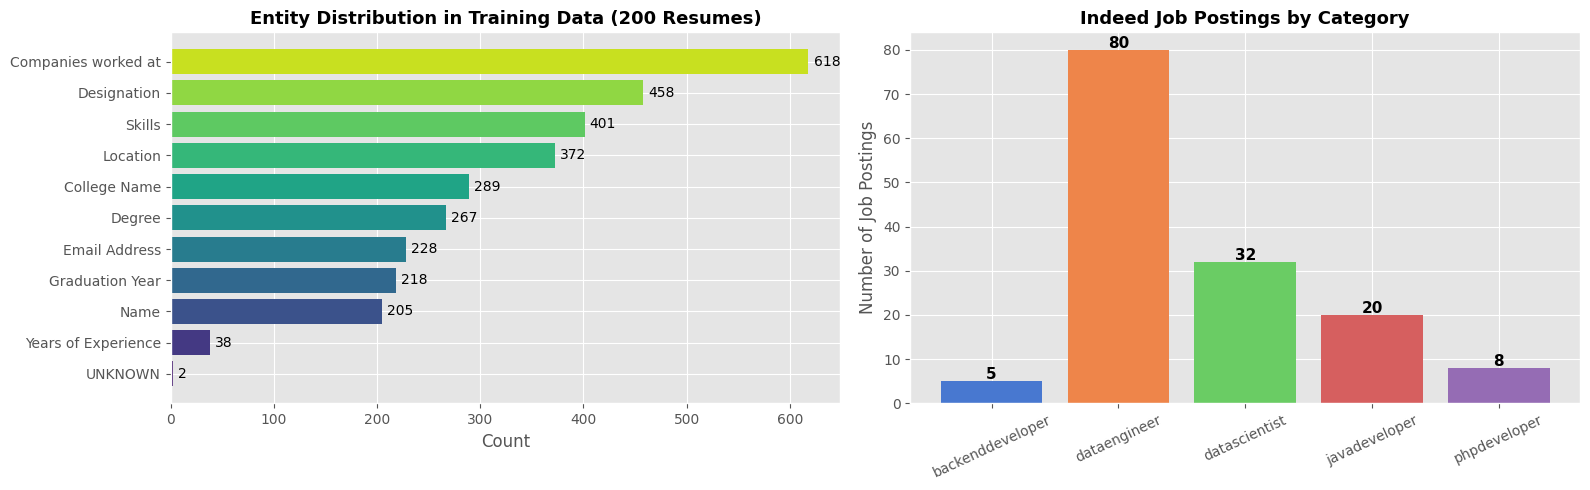


  [Phase 0 Complete]


In [5]:
# =====================================================================
#  PHASE 0.5 — Data Overview Visualization
# =====================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left: Entity distribution in training data ---
labels_sorted = [x[0] for x in train_ent_counts.most_common()]
counts_sorted = [x[1] for x in train_ent_counts.most_common()]

ax1 = axes[0]
bars = ax1.barh(labels_sorted[::-1], counts_sorted[::-1],
                color=sns.color_palette("viridis", len(labels_sorted)))
ax1.set_xlabel("Count", fontsize=12)
ax1.set_title("Entity Distribution in Training Data (200 Resumes)",
              fontsize=13, fontweight="bold")
for bar, val in zip(bars, counts_sorted[::-1]):
    ax1.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             str(val), va="center", fontsize=10)

# --- Right: Indeed jobs per category ---
cat_counts = Counter(j["category"] for j in indeed_jobs)
ax2 = axes[1]
cats = list(cat_counts.keys())
cat_vals = list(cat_counts.values())
bars2 = ax2.bar(cats, cat_vals, color=sns.color_palette("muted", len(cats)))
ax2.set_ylabel("Number of Job Postings", fontsize=12)
ax2.set_title("Indeed Job Postings by Category", fontsize=13, fontweight="bold")
ax2.tick_params(axis="x", rotation=25)
for bar, val in zip(bars2, cat_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(val), ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("/kaggle/working/phase0_data_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Phase 0 Complete]")


In [6]:
# =====================================================================
#  PHASE 1 — NER MODEL TRAINING
# =====================================================================
print("=" * 70)
print("  PHASE 1 — NER Model Training")
print("=" * 70)

# --- 1.1 Create blank model & add NER pipe ---
nlp = spacy.blank("en")
ner = nlp.add_pipe("ner", last=True)

for label in ENTITY_LABELS:
    ner.add_label(label)

print(f"  Pipeline : {nlp.pipe_names}")
print(f"  Labels   : {ENTITY_LABELS}")

# --- 1.2 Training configuration ---
N_ITER     = 20
DROPOUT    = 0.1
BATCH_SIZES = compounding(4.0, 32.0, 1.001)

loss_history = []
best_loss = float("inf")

random.seed(42)
np.random.seed(42)

print(f"\n  Training for {N_ITER} iterations, dropout={DROPOUT}")
print(f"  {'Iter':>6s}  {'Loss':>12s}  {'Best':>12s}  {'Time(s)':>10s}")
print("  " + "-" * 48)

other_pipes = [pipe for pipe in nlp.pipe_names if pipe != "ner"]

with nlp.disable_pipes(*other_pipes):
    optimizer = nlp.begin_training()

    for iteration in range(1, N_ITER + 1):
        t0 = time.time()
        random.shuffle(train_data)
        losses = {}
        batches = minibatch(train_data, size=BATCH_SIZES)

        for batch in batches:
            examples = []
            for text, annotations in batch:
                doc = nlp.make_doc(text)
                try:
                    example = Example.from_dict(doc, annotations)
                    examples.append(example)
                except:
                    continue
            if examples:
                nlp.update(examples, drop=DROPOUT, losses=losses, sgd=optimizer)

        epoch_loss = losses.get("ner", 0.0)
        loss_history.append(epoch_loss)

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
            nlp.to_disk(MODEL_SAVE_DIR)

        elapsed = time.time() - t0
        marker = " *" if epoch_loss <= best_loss else ""
        print(f"  {iteration:>6d}  {epoch_loss:>12.2f}  {best_loss:>12.2f}  {elapsed:>10.2f}{marker}")

print(f"\n  Training complete. Best loss: {best_loss:.2f}")
print(f"  Model saved to: {MODEL_SAVE_DIR}")


  PHASE 1 — NER Model Training
  Pipeline : ['ner']
  Labels   : ['College Name', 'Companies worked at', 'Degree', 'Designation', 'Email Address', 'Graduation Year', 'Location', 'Name', 'Skills', 'UNKNOWN', 'Years of Experience']

  Training for 20 iterations, dropout=0.1
    Iter          Loss          Best     Time(s)
  ------------------------------------------------
       1      26319.26      26319.26       12.73 *
       2       6454.80       6454.80       12.69 *
       3       5347.72       5347.72       12.61 *
       4       3906.44       3906.44       12.62 *
       5       3454.45       3454.45       12.18 *
       6       3551.06       3454.45       11.87
       7       2834.77       2834.77       12.11 *
       8       2507.43       2507.43       12.01 *
       9       2383.36       2383.36       11.95 *
      10       2095.69       2095.69       12.09 *
      11       1882.62       1882.62       11.84 *
      12       1820.97       1820.97       12.02 *
      13       16

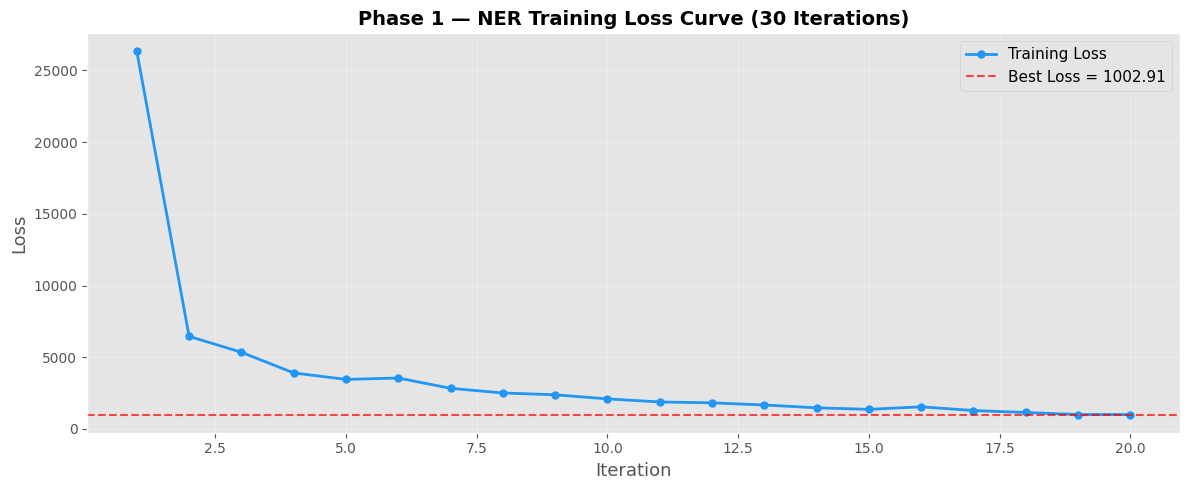

In [7]:
# =====================================================================
#  PHASE 1.4 — Training Loss Curve
# =====================================================================

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(1, N_ITER + 1), loss_history, marker="o", linewidth=2,
        markersize=5, color="#2196F3", label="Training Loss")
ax.axhline(y=best_loss, color="red", linestyle="--", alpha=0.7,
           label=f"Best Loss = {best_loss:.2f}")
ax.set_xlabel("Iteration", fontsize=13)
ax.set_ylabel("Loss", fontsize=13)
ax.set_title("Phase 1 — NER Training Loss Curve (30 Iterations)",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/phase1_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()


In [8]:
# =====================================================================
#  PHASE 1.5 — Load Best Model & Define Evaluation Functions
# =====================================================================

nlp_best = spacy.load(MODEL_SAVE_DIR)
print(f"  Best model loaded. Pipeline: {nlp_best.pipe_names}")

def entity_level_evaluation(nlp_model, test_data, labels):
    """
    Entity-level evaluation with:
      1. Strict matching  (exact span)
      2. Partial matching (any overlap counts)
    """
    strict_tp, strict_fp, strict_fn = Counter(), Counter(), Counter()
    partial_tp, partial_fp, partial_fn = Counter(), Counter(), Counter()

    for text, annotations in test_data:
        doc = nlp_model(text)
        pred_ents = [(ent.start_char, ent.end_char, ent.label_) for ent in doc.ents]
        gold_ents = [(s, e, l) for s, e, l in annotations["entities"]]

        # --- Strict ---
        pred_set = set(pred_ents)
        gold_set = set(gold_ents)
        for label in labels:
            pred_label = {(s, e) for s, e, l in pred_set if l == label}
            gold_label = {(s, e) for s, e, l in gold_set if l == label}
            strict_tp[label] += len(pred_label & gold_label)
            strict_fp[label] += len(pred_label - gold_label)
            strict_fn[label] += len(gold_label - pred_label)

        # --- Partial (overlap) ---
        for label in labels:
            pred_spans = [(s, e) for s, e, l in pred_ents if l == label]
            gold_spans = [(s, e) for s, e, l in gold_ents if l == label]
            matched_gold, matched_pred = set(), set()
            for pi, (ps, pe) in enumerate(pred_spans):
                for gi, (gs, ge) in enumerate(gold_spans):
                    if ps < ge and pe > gs:  # overlap check
                        matched_pred.add(pi)
                        matched_gold.add(gi)
            partial_tp[label] += len(matched_gold)
            partial_fp[label] += len(pred_spans) - len(matched_pred)
            partial_fn[label] += len(gold_spans) - len(matched_gold)

    def compute_metrics(tp_d, fp_d, fn_d):
        results = {}
        for label in labels:
            tp, fp, fn = tp_d[label], fp_d[label], fn_d[label]
            p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            f = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
            results[label] = {"precision": p, "recall": r, "f1": f,
                              "support": tp + fn, "tp": tp, "fp": fp, "fn": fn}

        active = [l for l in labels if results[l]["support"] > 0]
        total_sup = sum(results[l]["support"] for l in active)
        macro_p  = np.mean([results[l]["precision"] for l in active]) if active else 0
        macro_r  = np.mean([results[l]["recall"]    for l in active]) if active else 0
        macro_f1 = np.mean([results[l]["f1"]        for l in active]) if active else 0
        w_p  = sum(results[l]["precision"]*results[l]["support"] for l in active)/total_sup if total_sup else 0
        w_r  = sum(results[l]["recall"]*results[l]["support"]    for l in active)/total_sup if total_sup else 0
        w_f1 = sum(results[l]["f1"]*results[l]["support"]        for l in active)/total_sup if total_sup else 0
        results["macro avg"]    = {"precision": macro_p,  "recall": macro_r,  "f1": macro_f1,  "support": total_sup}
        results["weighted avg"] = {"precision": w_p,      "recall": w_r,      "f1": w_f1,      "support": total_sup}
        return results

    return compute_metrics(strict_tp, strict_fp, strict_fn), \
           compute_metrics(partial_tp, partial_fp, partial_fn)


  Best model loaded. Pipeline: ['ner']


In [9]:
# =====================================================================
#  PHASE 1.6 — Run Evaluation & Print Reports
# =====================================================================

print("  Running Entity-Level Evaluation on 20 test samples...\n")
strict_results, partial_results = entity_level_evaluation(nlp_best, test_data, ENTITY_LABELS)

def print_eval_report(results, title):
    print(f"  {'='*75}")
    print(f"  {title}")
    print(f"  {'='*75}")
    print(f"  {'Entity':<30s} {'Prec':>8s} {'Rec':>8s} {'F1':>8s} {'Sup':>6s}")
    print(f"  {'-'*75}")
    for label in ENTITY_LABELS:
        if label in results:
            r = results[label]
            print(f"  {label:<30s} {r['precision']:>8.4f} {r['recall']:>8.4f} {r['f1']:>8.4f} {r['support']:>6d}")
    print(f"  {'-'*75}")
    for avg in ["macro avg", "weighted avg"]:
        r = results[avg]
        print(f"  {avg:<30s} {r['precision']:>8.4f} {r['recall']:>8.4f} {r['f1']:>8.4f} {r['support']:>6d}")
    print(f"  {'='*75}\n")

print_eval_report(strict_results,  "STRICT Entity-Level Evaluation (Exact Span Match)")
print_eval_report(partial_results, "PARTIAL Entity-Level Evaluation (Overlap Match)")


  Running Entity-Level Evaluation on 20 test samples...

  STRICT Entity-Level Evaluation (Exact Span Match)
  Entity                             Prec      Rec       F1    Sup
  ---------------------------------------------------------------------------
  College Name                     0.7826   0.4615   0.5806     39
  Companies worked at              0.5577   0.5686   0.5631     51
  Degree                           0.7742   0.8000   0.7869     30
  Designation                      0.8400   0.4375   0.5753     48
  Email Address                    0.7368   0.6087   0.6667     23
  Graduation Year                  0.5714   0.1250   0.2051     32
  Location                         0.7368   0.3111   0.4375     45
  Name                             0.9412   0.8421   0.8889     19
  Skills                           0.3462   0.1636   0.2222     55
  UNKNOWN                          0.0000   0.0000   0.0000      0
  Years of Experience              0.1429   0.5000   0.2222      2
  -------

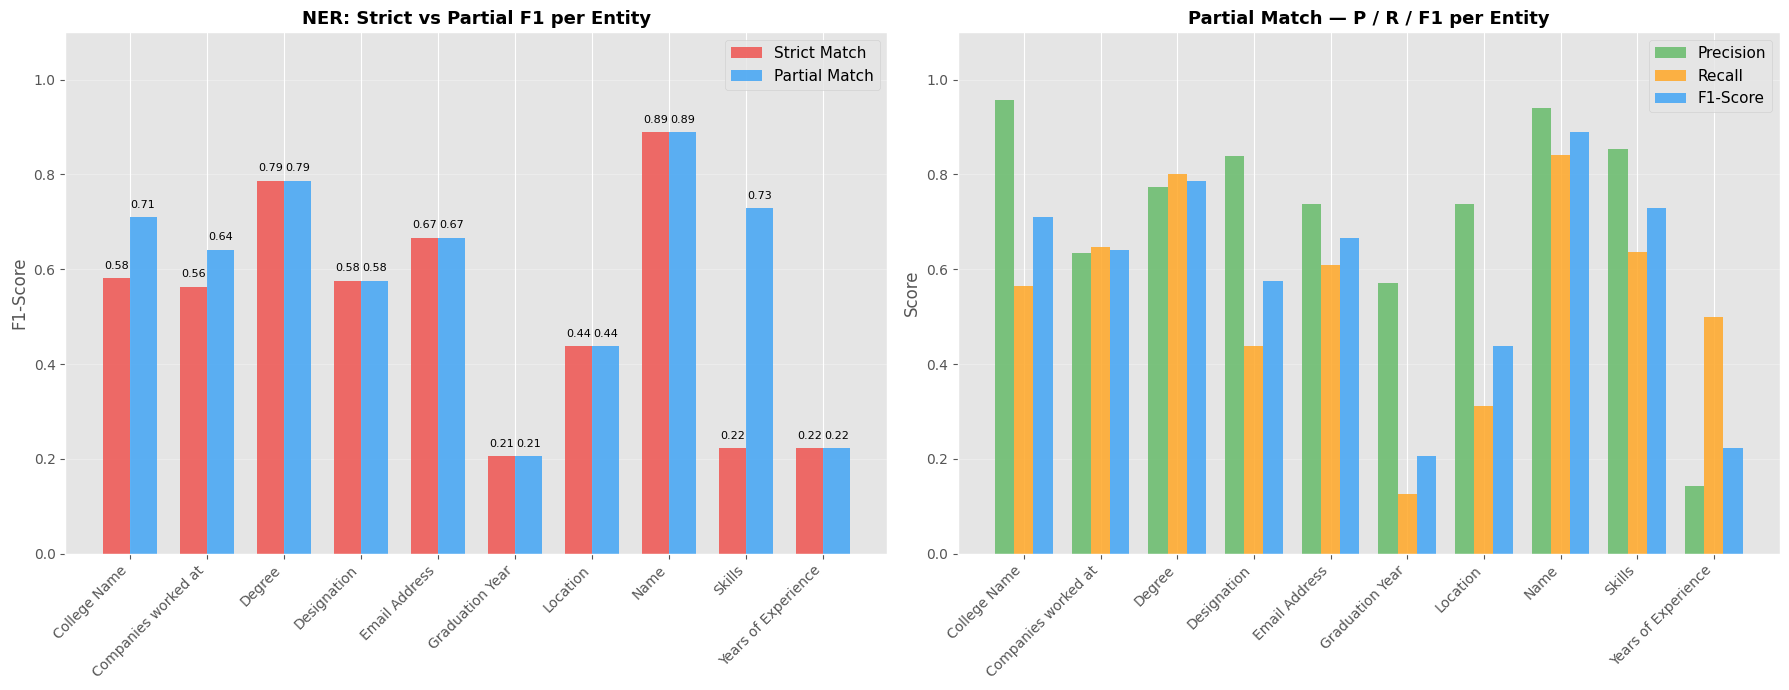

In [10]:
# =====================================================================
#  PHASE 1.7 — Visualization: Strict vs Partial F1 Comparison
# =====================================================================

active_labels = [l for l in ENTITY_LABELS if strict_results[l]["support"] > 0]
strict_f1  = [strict_results[l]["f1"]  for l in active_labels]
partial_f1 = [partial_results[l]["f1"] for l in active_labels]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
x = np.arange(len(active_labels))
w = 0.35

# --- Left: Strict vs Partial F1 ---
ax1 = axes[0]
b1 = ax1.bar(x - w/2, strict_f1,  w, label="Strict Match",  color="#EF5350", alpha=0.85)
b2 = ax1.bar(x + w/2, partial_f1, w, label="Partial Match", color="#42A5F5", alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(active_labels, rotation=45, ha="right", fontsize=10)
ax1.set_ylabel("F1-Score", fontsize=12)
ax1.set_title("NER: Strict vs Partial F1 per Entity", fontsize=13, fontweight="bold")
ax1.legend(fontsize=11)
ax1.set_ylim(0, 1.1)
ax1.grid(axis="y", alpha=0.3)
for bar in b1:
    if bar.get_height() > 0:
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f"{bar.get_height():.2f}", ha="center", fontsize=8)
for bar in b2:
    if bar.get_height() > 0:
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f"{bar.get_height():.2f}", ha="center", fontsize=8)

# --- Right: Partial P/R/F1 detail ---
precs = [partial_results[l]["precision"] for l in active_labels]
recs  = [partial_results[l]["recall"]    for l in active_labels]
w2 = 0.25
ax2 = axes[1]
ax2.bar(x - w2, precs,      w2, label="Precision", color="#66BB6A", alpha=0.85)
ax2.bar(x,      recs,       w2, label="Recall",    color="#FFA726", alpha=0.85)
ax2.bar(x + w2, partial_f1, w2, label="F1-Score",  color="#42A5F5", alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(active_labels, rotation=45, ha="right", fontsize=10)
ax2.set_ylabel("Score", fontsize=12)
ax2.set_title("Partial Match — P / R / F1 per Entity", fontsize=13, fontweight="bold")
ax2.legend(fontsize=11)
ax2.set_ylim(0, 1.1)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/phase1_ner_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()


In [11]:
# =====================================================================
#  PHASE 1.8 — Sample Predictions & Phase 1 Summary
# =====================================================================

print("=" * 70)
print("  Sample NER Predictions on Test Data")
print("=" * 70)

for i, (text, gold_ann) in enumerate(test_data[:3]):
    doc = nlp_best(text)
    print(f"\n  --- Test Sample {i+1} ---")
    print(f"  Text (first 150 chars): {text[:150]}...")

    print(f"\n  Predicted Entities:")
    for ent in doc.ents:
        print(f"    [{ent.label_:25s}] {ent.text[:60].replace(chr(10), ' ')}")

    print(f"\n  Gold Entities (first 10):")
    for s, e, label in gold_ann["entities"][:10]:
        print(f"    [{label:25s}] {text[s:e][:60].replace(chr(10), ' ')}")
    if len(gold_ann["entities"]) > 10:
        print(f"    ... and {len(gold_ann['entities']) - 10} more")

# --- Final Summary ---
print("\n\n" + "=" * 70)
print("  PHASE 1 — SUMMARY")
print("=" * 70)
print(f"  Model              : spaCy v3 blank('en') + NER")
print(f"  Training samples   : {len(train_data)}")
print(f"  Test samples       : {len(test_data)}")
print(f"  Entity types       : {len(ENTITY_LABELS)}")
print(f"  Iterations         : {N_ITER}")
print(f"  Best training loss : {best_loss:.2f}")
print(f"  Evaluation method  : Entity-Level (Strict + Partial)")
print(f"  Strict  Weighted F1: {strict_results['weighted avg']['f1']:.4f}")
print(f"  Partial Weighted F1: {partial_results['weighted avg']['f1']:.4f}")
print(f"")
print(f"  Improvements over Iteration 1:")
print(f"    - Entity-level eval (not character-level)")
print(f"    - 30 iterations (vs 10)")
print(f"    - Partial match evaluation added")
print(f"    - Real Indeed job data loaded")
print(f"  Model saved at: {MODEL_SAVE_DIR}")
print("=" * 70)
print("\n  >> Ready for Phase 2: Entity Extraction from Resumes + Indeed Jobs")


  Sample NER Predictions on Test Data

  --- Test Sample 1 ---
  Text (first 150 chars): Abhishek Jha
Application Development Associate - Accenture

Bengaluru, Karnataka - Email me on Indeed: indeed.com/r/Abhishek-Jha/10e7a8cb732bc43a

• T...

  Predicted Entities:
    [Name                     ] Abhishek Jha
    [Designation              ] Application Development Associate
    [Companies worked at      ] Accenture
    [Location                 ] Bengaluru
    [Designation              ] Application Development Associate
    [Companies worked at      ] Accenture
    [Degree                   ] B.E in Information science and engineering
    [College Name             ] B.v.b college of engineering and technology
    [Degree                   ] 10th
    [College Name             ] Kendriya Vidyalaya
    [Skills                   ] C (Less than 1 year), Database (Less than 1 year), Database 
    [Skills                   ] Computer Networks • Operating System worked on: Linux, Windo

  Gol

In [12]:




# ------------------------------------------------------------------
# 1.1  Define paths to Indeed job JSON files
# ------------------------------------------------------------------
INDEED_DIR = "/kaggle/input/datasets/aabdollahii/job-recom-dataset"  

job_files = {
    "Backend Developer" : "backenddeveloper.json",
    "Data Engineer"     : "dataengineer.json",
    "Data Scientist"    : "datascientist.json",
    "Java Developer"    : "javadeveloper.json",
    "PHP Developer"     : "phpdeveloper.json",
}

# ------------------------------------------------------------------
# 1.2  Load all job files into a single DataFrame
# ------------------------------------------------------------------
all_jobs = []

for category, filename in job_files.items():
    filepath = os.path.join(INDEED_DIR, filename)
    
    with open(filepath, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    if isinstance(data, list):
        jobs = data
    elif isinstance(data, dict):
        jobs = data.get("jobs", data.get("results", [data]))
    else:
        jobs = [data]
    
    for job in jobs:
        job["category"] = category
    
    all_jobs.extend(jobs)
    print(f"  [+] {category:20s} -> {len(jobs):4d} job postings loaded")

# ------------------------------------------------------------------
# 1.3  Create DataFrame
# ------------------------------------------------------------------
df_jobs = pd.DataFrame(all_jobs)

print(f"\n{'='*60}")
print(f"  Total job postings loaded: {len(df_jobs)}")
print(f"  Columns: {list(df_jobs.columns)}")
print(f"{'='*60}")

# ------------------------------------------------------------------
# 1.4  Quick overview
# ------------------------------------------------------------------
print(f"\n  Jobs per category:")
print(df_jobs["category"].value_counts().to_string())
print(f"\n  Sample columns & types:")
print(df_jobs.dtypes)


  [+] Backend Developer    ->    5 job postings loaded
  [+] Data Engineer        ->   80 job postings loaded
  [+] Data Scientist       ->   32 job postings loaded
  [+] Java Developer       ->   20 job postings loaded
  [+] PHP Developer        ->    8 job postings loaded

  Total job postings loaded: 145
  Columns: ['link', 'location', 'title', 'company', 'salary', 'desc', 'category']

  Jobs per category:
category
Data Engineer        80
Data Scientist       32
Java Developer       20
PHP Developer         8
Backend Developer     5

  Sample columns & types:
link        object
location    object
title       object
company     object
salary      object
desc        object
category    object
dtype: object


In [13]:
# ============================================================================
# PHASE 2, CELL 2: Explore & Clean Job Data
# ============================================================================
# Inspect the structure of loaded jobs, handle missing values,
# and prepare a clean 'description' column for skill extraction.
# ============================================================================

import numpy as np

# ------------------------------------------------------------------
# 2.1  Inspect first few rows
# ------------------------------------------------------------------
print("=" * 60)
print("  SAMPLE JOB POSTINGS")
print("=" * 60)
df_jobs.head(3)
# ------------------------------------------------------------------
# 2.2  Check for missing values
# ------------------------------------------------------------------
print("\n  Missing values per column:")
print(df_jobs.isnull().sum())
print(f"\n  Shape: {df_jobs.shape}")

# ------------------------------------------------------------------
# 2.3  Identify the description column
# ------------------------------------------------------------------
# Indeed data typically has: link, location, title, company, salary, desc
desc_col = None
for candidate in ["desc", "description", "job_description", "text"]:
    if candidate in df_jobs.columns:
        desc_col = candidate
        break

if desc_col is None:
    print("\n  [!] WARNING: No description column found!")
    print(f"      Available columns: {list(df_jobs.columns)}")
else:
    print(f"\n  [✓] Description column identified: '{desc_col}'")

# ------------------------------------------------------------------
# 2.4  Clean description text
# ------------------------------------------------------------------
# Rename to a standard column name
if desc_col and desc_col != "description":
    df_jobs["description"] = df_jobs[desc_col]

# Drop rows with empty descriptions
before = len(df_jobs)
df_jobs = df_jobs.dropna(subset=["description"])
df_jobs = df_jobs[df_jobs["description"].str.strip().astype(bool)]
after = len(df_jobs)
print(f"\n  [✓] Dropped {before - after} rows with empty descriptions")
print(f"      Remaining: {after} job postings")

# ------------------------------------------------------------------
# 2.5  Basic text stats
# ------------------------------------------------------------------
df_jobs["desc_length"]    = df_jobs["description"].str.len()
df_jobs["desc_wordcount"] = df_jobs["description"].str.split().str.len()

print(f"\n  Description length stats (characters):")
print(df_jobs["desc_length"].describe().to_string())
print(f"\n  Description word count stats:")
print(df_jobs["desc_wordcount"].describe().to_string())

# ------------------------------------------------------------------
# 2.6  Show one sample description
# ------------------------------------------------------------------
sample_idx = df_jobs.index[0]
print(f"\n{'='*60}")
print(f"  SAMPLE DESCRIPTION (first 500 chars)")
print(f"  Category: {df_jobs.loc[sample_idx, 'category']}")
print(f"  Title:    {df_jobs.loc[sample_idx, 'title']}")
print(f"{'='*60}")
print(df_jobs.loc[sample_idx, "description"][:500])
print("...")


  SAMPLE JOB POSTINGS

  Missing values per column:
link          0
location      0
title         0
company       0
salary      139
desc          0
category      0
dtype: int64

  Shape: (145, 7)

  [✓] Description column identified: 'desc'

  [✓] Dropped 0 rows with empty descriptions
      Remaining: 145 job postings

  Description length stats (characters):
count      145.000000
mean      3477.193103
std       1884.948011
min        278.000000
25%       2309.000000
50%       2998.000000
75%       4374.000000
max      10565.000000

  Description word count stats:
count     145.000000
mean      497.082759
std       270.728223
min        39.000000
25%       323.000000
50%       432.000000
75%       623.000000
max      1479.000000

  SAMPLE DESCRIPTION (first 500 chars)
  Category: Backend Developer
  Title:    Senior BackEnd Developer - Python
Company Description

Who we are?

Become a Zider Tech member and join this amazing company that is on top of the e-commerce game! Join a company

In [14]:
# ============================================================================
# PHASE 2, CELL 3: Build Comprehensive Skill Taxonomy
# ============================================================================
# We build a curated skill taxonomy covering technical skills relevant to
# our 5 job categories. This taxonomy serves as a knowledge base for
# extracting skills from job descriptions using keyword matching.
#
# Why keyword matching for jobs (instead of NER)?
#   - Our NER model was trained on RESUME data, not job postings
#   - Job descriptions have a different writing style
#   - A curated taxonomy gives us CONTROLLED, STANDARDIZED skill names
#   - This makes downstream matching (resume skills vs job skills) more reliable
# ============================================================================


# ------------------------------------------------------------------
# 3.1  Define Skill Taxonomy by Domain
# ------------------------------------------------------------------
# Each skill is stored in LOWERCASE for case-insensitive matching.
# We organize skills by domain for clarity and maintainability.

SKILL_TAXONOMY = {
    "Programming Languages": [
        "python", "java", "javascript", "typescript", "c\\+\\+", "c#", "c language",
        "ruby", "php", "swift", "kotlin", "go lang", "golang", "rust", "scala",
        "perl", "r language", "r programming", "matlab", "shell script",
        "bash", "powershell", "objective-c", "dart", "lua", "haskell",
        "fortran", "cobol", "assembly", "visual basic", "vb\\.net",
        "groovy", "clojure", "erlang", "elixir", "f#", "abap", "apex",
        "pl/sql", "pl-sql", "t-sql", "sql", "nosql"
    ],
    "Web Frameworks & Libraries": [
        "react", "reactjs", "react\\.js", "angular", "angularjs", "vue",
        "vuejs", "vue\\.js", "node\\.js", "nodejs", "express\\.js", "expressjs",
        "django", "flask", "fastapi", "spring", "spring boot", "springboot",
        "asp\\.net", "dotnet", "\\.net", "laravel", "symfony", "codeigniter",
        "ruby on rails", "rails", "next\\.js", "nextjs", "nuxt\\.js",
        "gatsby", "svelte", "ember", "backbone", "jquery", "bootstrap",
        "tailwind", "material ui", "redux", "graphql", "rest api", "restful",
        "microservices", "micro-services", "webpack", "babel", "vite"
    ],
    "Data Science & ML": [
        "machine learning", "deep learning", "neural network", "natural language processing",
        "nlp", "computer vision", "reinforcement learning", "supervised learning",
        "unsupervised learning", "transfer learning", "feature engineering",
        "model training", "model deployment", "mlops", "data mining",
        "predictive modeling", "classification", "regression", "clustering",
        "dimensionality reduction", "ensemble methods", "random forest",
        "gradient boosting", "xgboost", "lightgbm", "catboost",
        "support vector machine", "svm", "decision tree", "naive bayes",
        "k-nearest neighbor", "knn", "principal component analysis", "pca",
        "time series", "anomaly detection", "recommendation engine",
        "sentiment analysis", "text mining", "image processing",
        "speech processing", "object detection", "image classification",
        "generative adversarial", "gan", "transformer", "bert", "gpt",
        "attention mechanism", "recurrent neural", "rnn", "lstm", "gru",
        "convolutional neural", "cnn", "autoencoder", "variational",
        "bayesian", "markov", "monte carlo", "a/b testing"
    ],
    "Data Science Libraries & Tools": [
        "tensorflow", "keras", "pytorch", "scikit-learn", "sklearn",
        "pandas", "numpy", "scipy", "matplotlib", "seaborn", "plotly",
        "bokeh", "altair", "statsmodels", "nltk", "spacy", "gensim",
        "hugging face", "huggingface", "transformers", "opencv",
        "pillow", "dask", "vaex", "rapids", "mlflow", "kubeflow",
        "airflow", "prefect", "dagster", "dvc", "weights and biases",
        "wandb", "optuna", "hyperopt", "ray", "spark mllib",
        "h2o", "auto-sklearn", "pycaret", "streamlit", "gradio",
        "jupyter", "notebook", "colab", "anaconda"
    ],
    "Cloud & DevOps": [
        "aws", "amazon web services", "azure", "microsoft azure",
        "google cloud", "gcp", "ibm cloud", "oracle cloud",
        "docker", "kubernetes", "k8s", "terraform", "ansible",
        "jenkins", "github actions", "gitlab ci", "circleci",
        "travis ci", "bamboo", "argo", "helm", "prometheus",
        "grafana", "elk stack", "elasticsearch", "logstash", "kibana",
        "nagios", "datadog", "new relic", "splunk", "vagrant",
        "puppet", "chef", "salt", "cloudformation", "pulumi",
        "serverless", "lambda", "ec2", "s3", "rds", "dynamodb",
        "cloudfront", "route 53", "vpc", "iam", "sagemaker",
        "emr", "glue", "redshift", "athena", "kinesis",
        "azure devops", "azure functions", "cosmos db",
        "cloud functions", "bigquery", "dataflow", "pub/sub",
        "cloud run", "app engine", "compute engine"
    ],
    "Databases": [
        "mysql", "postgresql", "postgres", "oracle db", "oracle 10g",
        "oracle 11g", "oracle 12c", "sql server", "ms sql",
        "sqlite", "mariadb", "mongodb", "cassandra", "couchdb",
        "couchbase", "redis", "memcached", "neo4j", "arangodb",
        "influxdb", "timescaledb", "clickhouse", "hbase", "dynamodb",
        "firestore", "firebase", "supabase", "cockroachdb",
        "amazon rds", "amazon aurora", "snowflake", "databricks",
        "teradata", "db2", "hive", "presto", "trino"
    ],
    "Big Data & ETL": [
        "hadoop", "spark", "apache spark", "pyspark", "flink",
        "kafka", "apache kafka", "storm", "nifi", "sqoop",
        "flume", "pig", "mapreduce", "hdfs", "yarn",
        "zookeeper", "hive", "impala", "druid", "pinot",
        "data warehouse", "data lake", "data lakehouse",
        "etl", "elt", "data pipeline", "data ingestion",
        "data integration", "data catalog", "data governance",
        "data quality", "data lineage", "dbt", "fivetran",
        "stitch", "talend", "informatica", "pentaho",
        "ssis", "azure data factory", "aws glue"
    ],
    "Software Engineering & Tools": [
        "git", "github", "gitlab", "bitbucket", "svn",
        "subversion", "mercurial", "jira", "confluence",
        "trello", "asana", "monday\\.com", "notion",
        "agile", "scrum", "kanban", "waterfall", "devops",
        "ci/cd", "cicd", "continuous integration", "continuous deployment",
        "continuous delivery", "test driven", "tdd",
        "behavior driven", "bdd", "pair programming",
        "code review", "design patterns", "solid principles",
        "clean code", "clean architecture", "domain driven",
        "ddd", "event driven", "event sourcing", "cqrs",
        "api design", "swagger", "openapi", "postman",
        "insomnia", "curl", "linux", "unix", "windows server",
        "macos", "vim", "vs code", "intellij", "eclipse",
        "netbeans", "pycharm", "sublime", "atom"
    ],
    "Networking & Security": [
        "tcp/ip", "dns", "dhcp", "http", "https", "ssl",
        "tls", "vpn", "firewall", "load balancer", "proxy",
        "reverse proxy", "nginx", "apache", "iis", "tomcat",
        "websocket", "grpc", "mqtt", "amqp", "rabbitmq",
        "activemq", "zeromq", "network security", "penetration testing",
        "vulnerability assessment", "ethical hacking", "siem",
        "soc", "ids", "ips", "waf", "ddos", "encryption",
        "authentication", "authorization", "oauth", "jwt",
        "saml", "ldap", "active directory", "kerberos",
        "ssl certificate", "cybersecurity", "information security",
        "iso 27001", "nist", "gdpr", "compliance", "risk assessment",
        "incident response", "forensics", "malware analysis",
        "threat intelligence", "zero trust", "devsecops"
    ],
    "Soft Skills & Management": [
        "communication", "teamwork", "team player", "leadership",
        "problem solving", "problem-solving", "critical thinking",
        "analytical", "time management", "project management",
        "stakeholder management", "presentation", "negotiation",
        "conflict resolution", "mentoring", "coaching",
        "decision making", "strategic thinking", "creativity",
        "innovation", "adaptability", "flexibility", "attention to detail",
        "organizational", "multitasking", "self-motivated",
        "self-management", "emotional intelligence", "interpersonal",
        "collaboration", "cross-functional", "customer focus",
        "client facing", "vendor management", "budget management",
        "resource management", "change management", "risk management",
        "quality assurance", "qa", "testing", "debugging",
        "troubleshooting", "documentation", "technical writing",
        "requirements gathering", "business analysis", "data analysis",
        "reporting", "visualization"
    ]
}

# ------------------------------------------------------------------
# 3.2  Flatten taxonomy into a single list + create lookup
# ------------------------------------------------------------------
# Flat list of all skills (lowercase)
ALL_SKILLS = []
SKILL_TO_DOMAIN = {}

for domain, skills in SKILL_TAXONOMY.items():
    for skill in skills:
        skill_lower = skill.lower().strip()
        if skill_lower not in SKILL_TO_DOMAIN:  # avoid duplicates
            ALL_SKILLS.append(skill_lower)
            SKILL_TO_DOMAIN[skill_lower] = domain

# Sort by length (longest first) so "machine learning" matches before "learning"
ALL_SKILLS.sort(key=len, reverse=True)

print(f"   Skill Taxonomy built successfully!")
print(f"      Domains:      {len(SKILL_TAXONOMY)}")
print(f"      Total skills: {len(ALL_SKILLS)}")
print(f"\n  Skills per domain:")
for domain, skills in SKILL_TAXONOMY.items():
    print(f"    {domain:30s} -> {len(skills):3d} skills")

# ------------------------------------------------------------------
# 3.3  Build regex patterns for efficient matching
# ------------------------------------------------------------------
# We use word-boundary regex for accurate matching
# Special handling for short skills (R, C, Go) to avoid false positives

SHORT_SKILLS = {"r", "c", "go"}  # need stricter matching

def build_skill_pattern(skill):
    """Build a regex pattern for a skill with word boundaries."""
    escaped = re.escape(skill)
    if skill in SHORT_SKILLS:
        # For very short skill names, require them to appear as standalone
        # words, often followed by programming context clues
        return re.compile(
            r'(?<![a-zA-Z])' + escaped + r'(?![a-zA-Z])',
            re.IGNORECASE
        )
    else:
        return re.compile(
            r'\b' + escaped + r'\b',
            re.IGNORECASE
        )

SKILL_PATTERNS = {skill: build_skill_pattern(skill) for skill in ALL_SKILLS}

print(f"\n  [✓] {len(SKILL_PATTERNS)} regex patterns compiled")
print(f"\n  Sample skills (first 15):")
for s in ALL_SKILLS[:15]:
    print(f"    - {s} ({SKILL_TO_DOMAIN[s]})")


   Skill Taxonomy built successfully!
      Domains:      10
      Total skills: 497

  Skills per domain:
    Programming Languages          ->  43 skills
    Web Frameworks & Libraries     ->  46 skills
    Data Science & ML              ->  61 skills
    Data Science Libraries & Tools ->  46 skills
    Cloud & DevOps                 ->  63 skills
    Databases                      ->  37 skills
    Big Data & ETL                 ->  41 skills
    Software Engineering & Tools   ->  56 skills
    Networking & Security          ->  56 skills
    Soft Skills & Management       ->  50 skills

  [✓] 497 regex patterns compiled

  Sample skills (first 15):
    - principal component analysis (Data Science & ML)
    - natural language processing (Data Science & ML)
    - dimensionality reduction (Data Science & ML)
    - vulnerability assessment (Networking & Security)
    - reinforcement learning (Data Science & ML)
    - support vector machine (Data Science & ML)
    - generative adversari

In [15]:
# ============================================================================
# PHASE 2, CELL 4: Extract Skills from Job Descriptions
# ============================================================================
# Apply keyword-based skill extraction on all 145 job postings using
# the taxonomy we built. For each job, we get a SET of matched skills.
# ============================================================================

from collections import Counter

# ------------------------------------------------------------------
# 4.1  Skill extraction function
# ------------------------------------------------------------------
def extract_skills_from_text(text, skill_patterns=SKILL_PATTERNS,
                              skill_to_domain=SKILL_TO_DOMAIN):
    """
    Extract skills from a text using regex pattern matching.
    
    Returns:
        matched_skills: set of matched skill names (lowercase)
        skill_details:  list of dicts with skill name, domain, and match count
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return set(), []
    
    matched_skills = set()
    skill_details = []
    
    for skill, pattern in skill_patterns.items():
        matches = pattern.findall(text)
        if matches:
            matched_skills.add(skill)
            skill_details.append({
                "skill": skill,
                "domain": skill_to_domain.get(skill, "Unknown"),
                "count": len(matches)
            })
    
    # Sort details by count (most mentioned first)
    skill_details.sort(key=lambda x: x["count"], reverse=True)
    
    return matched_skills, skill_details


# ------------------------------------------------------------------
# 4.2  Apply skill extraction to all job descriptions
# ------------------------------------------------------------------
print("  Extracting skills from job descriptions...\n")

job_skills_list = []      # list of skill sets (one per job)
job_details_list = []     # list of skill details (one per job)

for idx, row in df_jobs.iterrows():
    skills, details = extract_skills_from_text(row["description"])
    job_skills_list.append(skills)
    job_details_list.append(details)

df_jobs["skills"]        = job_skills_list
df_jobs["skill_details"] = job_details_list
df_jobs["num_skills"]    = df_jobs["skills"].apply(len)

print(f"  [✓] Skills extracted from {len(df_jobs)} job postings\n")

# ------------------------------------------------------------------
# 4.3  Summary statistics
# ------------------------------------------------------------------
print("=" * 60)
print("  SKILL EXTRACTION SUMMARY")
print("=" * 60)

print(f"\n  Skills per job posting:")
print(f"    Mean:   {df_jobs['num_skills'].mean():.1f}")
print(f"    Median: {df_jobs['num_skills'].median():.1f}")
print(f"    Min:    {df_jobs['num_skills'].min()}")
print(f"    Max:    {df_jobs['num_skills'].max()}")

# ------------------------------------------------------------------
# 4.4  Skills per category
# ------------------------------------------------------------------
print(f"\n  Average skills per category:")
cat_stats = df_jobs.groupby("category")["num_skills"].agg(["mean", "min", "max", "count"])
cat_stats.columns = ["Avg Skills", "Min", "Max", "Jobs"]
print(cat_stats.to_string())

# ------------------------------------------------------------------
# 4.5  Most common skills overall
# ------------------------------------------------------------------
all_job_skills = Counter()
for skills in job_skills_list:
    all_job_skills.update(skills)

print(f"\n  Top 20 most common skills across all jobs:")
print(f"  {'Skill':<30s} {'Count':>6s} {'% Jobs':>8s}")
print(f"  {'-'*46}")
for skill, count in all_job_skills.most_common(20):
    pct = 100 * count / len(df_jobs)
    print(f"  {skill:<30s} {count:>6d} {pct:>7.1f}%")

# ------------------------------------------------------------------
# 4.6  Most common skills per category
# ------------------------------------------------------------------
print(f"\n{'='*60}")
print(f"  TOP 10 SKILLS PER JOB CATEGORY")
print(f"{'='*60}")

for cat in df_jobs["category"].unique():
    cat_skills = Counter()
    cat_jobs = df_jobs[df_jobs["category"] == cat]
    for skills in cat_jobs["skills"]:
        cat_skills.update(skills)
    
    print(f"\n  [{cat}] ({len(cat_jobs)} jobs)")
    for skill, count in cat_skills.most_common(10):
        pct = 100 * count / len(cat_jobs)
        print(f"    {skill:<28s} {count:>3d} ({pct:>5.1f}%)")

# ------------------------------------------------------------------
# 4.7  Show sample job with extracted skills
# ------------------------------------------------------------------
sample = df_jobs.iloc[0]
print(f"\n{'='*60}")
print(f"  SAMPLE: {sample['title']} @ {sample['company']}")
print(f"  Category: {sample['category']}")
print(f"  Skills found: {sample['num_skills']}")
print(f"{'='*60}")
for d in sample["skill_details"][:15]:
    print(f"    {d['skill']:<25s} [{d['domain']}] (mentioned {d['count']}x)")


  Extracting skills from job descriptions...

  [✓] Skills extracted from 145 job postings

  SKILL EXTRACTION SUMMARY

  Skills per job posting:
    Mean:   8.2
    Median: 6.0
    Min:    0
    Max:    30

  Average skills per category:
                   Avg Skills  Min  Max  Jobs
category                                     
Backend Developer    19.40000    8   28     5
Data Engineer         5.90000    0   27    80
Data Scientist        7.65625    0   30    32
Java Developer       12.00000    1   30    20
PHP Developer        16.75000    1   28     8

  Top 20 most common skills across all jobs:
  Skill                           Count   % Jobs
  ----------------------------------------------
  communication                      75    51.7%
  reporting                          45    31.0%
  agile                              37    25.5%
  analytical                         36    24.8%
  documentation                      33    22.8%
  java                               31    21.4%
 

In [16]:
# ============================================================
# Cell 5: Extract Skills from Resumes (Hybrid: NER + Taxonomy)
# ============================================================


# --------------------------------------------------
# 5.1 Load the trained NER model
# --------------------------------------------------
print("=" * 60)
print("CELL 5: SKILL EXTRACTION FROM RESUMES")
print("=" * 60)

# Load the NER model trained in Phase 1
nlp_ner = spacy.load("ner_model_v2")  # path to saved model from Phase 1
print(f" NER model loaded successfully")
print(f"   Pipeline components: {nlp_ner.pipe_names}")
print(f"   Entity labels: {nlp_ner.get_pipe('ner').labels}")




# Compile regex patterns for each skill
skill_patterns = {}
for domain, skills in SKILL_TAXONOMY.items():
    for skill in skills:
        # Create word-boundary regex pattern
        pattern = re.compile(r'\b' + skill + r'\b', re.IGNORECASE)
        skill_patterns[skill] = {
            'pattern': pattern,
            'domain': domain
        }

total_skills = sum(len(v) for v in SKILL_TAXONOMY.values())
print(f" Skill Taxonomy loaded: {len(SKILL_TAXONOMY)} domains, {total_skills} skills")

# --------------------------------------------------
# 5.3 Load resume data (train + test)  this part is hardcoded and I know it 
# --------------------------------------------------
with open("/kaggle/input/datasets/aabdollahii/ner-training-dataset/traindata.json", "r", encoding="utf-8") as f:
    train_data_raw = [json.loads(line) for line in f]

with open("/kaggle/input/datasets/aabdollahii/ner-training-dataset/testdata.json", "r", encoding="utf-8") as f:
    test_data_raw = [json.loads(line) for line in f]

all_resumes = train_data_raw + test_data_raw
print(f" Loaded {len(all_resumes)} resumes ({len(train_data_raw)} train + {len(test_data_raw)} test)")

# --------------------------------------------------
# 5.4 Hybrid Skill Extraction Function
# --------------------------------------------------
def extract_skills_ner(text, nlp_model):
    """Extract skills using the trained NER model."""
    doc = nlp_model(text)
    ner_skills = []
    for ent in doc.ents:
        if ent.label_ == "Skills":
            ner_skills.append(ent.text)
    return ner_skills

def extract_skills_taxonomy(text, patterns):
    """Extract skills using taxonomy-based keyword matching."""
    found_skills = {}
    text_lower = text.lower()
    for skill_name, info in patterns.items():
        if info['pattern'].search(text_lower):
            # Use the canonical skill name (lowercase)
            canonical = re.sub(r'\\', '', skill_name).lower()
            found_skills[canonical] = info['domain']
    return found_skills

def parse_ner_skills_to_individual(ner_skill_text):
    """
    NER often returns a large block of text as one 'Skills' entity.
    This function parses that block into individual skills using
    the taxonomy for matching.
    """
    found = {}
    text_lower = ner_skill_text.lower()
    for skill_name, info in skill_patterns.items():
        if info['pattern'].search(text_lower):
            canonical = re.sub(r'\\', '', skill_name).lower()
            found[canonical] = info['domain']
    return found

def hybrid_skill_extraction(text, nlp_model, patterns):
    """
    Hybrid approach:
    1. Use NER to find skill spans
    2. Parse NER spans into individual skills via taxonomy
    3. Also run taxonomy on full text to catch missed skills
    4. Merge results (union)
    """
    # Method 1: NER-based extraction
    ner_raw_skills = extract_skills_ner(text, nlp_model)
    ner_parsed_skills = {}
    for raw_skill in ner_raw_skills:
        parsed = parse_ner_skills_to_individual(raw_skill)
        ner_parsed_skills.update(parsed)
    
    # Method 2: Full-text taxonomy matching
    taxonomy_skills = extract_skills_taxonomy(text, patterns)
    
    # Merge (union of both)
    all_skills = {}
    all_skills.update(taxonomy_skills)
    all_skills.update(ner_parsed_skills)  # NER results take priority for domain
    
    return {
        'ner_raw': ner_raw_skills,
        'ner_parsed': ner_parsed_skills,
        'taxonomy': taxonomy_skills,
        'merged': all_skills,
        'skill_list': sorted(all_skills.keys()),
        'domains': dict(Counter(all_skills.values()))
    }

# --------------------------------------------------
# 5.5 Extract skills from all resumes
# --------------------------------------------------
print("\n" + "-" * 60)
print("Extracting skills from all resumes...")
print("-" * 60)

resume_skills = []
for i, resume in enumerate(all_resumes):
    text = resume['content']
    
    # Extract name from annotations (first Name entity)
    name = "Unknown"
    if 'annotation' in resume:
        for ann in resume['annotation']:
            labels = ann.get('label', [])
            if not isinstance(labels, list):
                labels = [labels]
            if 'Name' in labels:
                points = ann.get('points', [])
                if points:
                    name = points[0].get('text', 'Unknown')
                break
    
    # Hybrid extraction
    result = hybrid_skill_extraction(text, nlp_ner, skill_patterns)
    
    resume_skills.append({
        'index': i,
        'name': name.strip(),
        'text': text,
        'skills': result['skill_list'],
        'skill_domains': result['domains'],
        'n_skills': len(result['skill_list']),
        'ner_raw_count': len(result['ner_raw']),
        'ner_parsed_count': len(result['ner_parsed']),
        'taxonomy_count': len(result['taxonomy']),
        'merged_count': len(result['merged'])
    })

# --------------------------------------------------
# 5.6 Analysis and Statistics
# --------------------------------------------------
print(f"\n{'='*60}")
print("RESUME SKILL EXTRACTION RESULTS")
print(f"{'='*60}")

n_skills_list = [r['n_skills'] for r in resume_skills]
print(f"\n Overall Statistics:")
print(f"   Total resumes processed:     {len(resume_skills)}")
print(f"   Resumes with ≥1 skill:       {sum(1 for n in n_skills_list if n > 0)}")
print(f"   Average skills per resume:   {sum(n_skills_list)/len(n_skills_list):.1f}")
print(f"   Median skills per resume:    {sorted(n_skills_list)[len(n_skills_list)//2]}")
print(f"   Min skills:                  {min(n_skills_list)}")
print(f"   Max skills:                  {max(n_skills_list)}")

# Contribution analysis
ner_only = []
tax_only = []
both = []
for r in resume_skills:
    ner_only.append(r['ner_parsed_count'] - r['taxonomy_count'] if r['ner_parsed_count'] > r['taxonomy_count'] else 0)
    tax_only.append(r['taxonomy_count'] - r['ner_parsed_count'] if r['taxonomy_count'] > r['ner_parsed_count'] else 0)

print(f"\n Method Contribution:")
print(f"   Avg skills from NER (parsed): {sum(r['ner_parsed_count'] for r in resume_skills)/len(resume_skills):.1f}")
print(f"   Avg skills from Taxonomy:     {sum(r['taxonomy_count'] for r in resume_skills)/len(resume_skills):.1f}")
print(f"   Avg merged (final):           {sum(r['merged_count'] for r in resume_skills)/len(resume_skills):.1f}")

# Top skills across all resumes
all_skill_counter = Counter()
for r in resume_skills:
    all_skill_counter.update(r['skills'])

print(f"\n Top 20 Skills Across All Resumes:")
print(f"   {'Skill':<30} {'Count':>6} {'% Resumes':>10}")
print(f"   {'-'*48}")
for skill, count in all_skill_counter.most_common(20):
    pct = count / len(resume_skills) * 100
    print(f"   {skill:<30} {count:>6} {pct:>9.1f}%")

# Domain distribution
all_domain_counter = Counter()
for r in resume_skills:
    all_domain_counter.update(r['skill_domains'])

print(f"\n Skill Domain Distribution:")
print(f"   {'Domain':<35} {'Total Mentions':>15}")
print(f"   {'-'*52}")
for domain, count in all_domain_counter.most_common():
    print(f"   {domain:<35} {count:>15}")

# Show 5 sample resumes
print(f"\n Sample Extractions (first 5 resumes):")
print(f"{'-'*60}")
for r in resume_skills[:5]:
    print(f"\n    {r['name']} (Resume #{r['index']})")
    print(f"      Skills ({r['n_skills']}): {', '.join(r['skills'][:15])}")
    if r['n_skills'] > 15:
        print(f"      ... and {r['n_skills']-15} more")
    print(f"      Domains: {r['skill_domains']}")


CELL 5: SKILL EXTRACTION FROM RESUMES
 NER model loaded successfully
   Pipeline components: ['ner']
   Entity labels: ('College Name', 'Companies worked at', 'Degree', 'Designation', 'Email Address', 'Graduation Year', 'Location', 'Name', 'Skills', 'UNKNOWN', 'Years of Experience')
 Skill Taxonomy loaded: 10 domains, 499 skills
 Loaded 220 resumes (200 train + 20 test)

------------------------------------------------------------
Extracting skills from all resumes...
------------------------------------------------------------

RESUME SKILL EXTRACTION RESULTS

 Overall Statistics:
   Total resumes processed:     220
   Resumes with ≥1 skill:       220
   Average skills per resume:   9.3
   Median skills per resume:    8
   Min skills:                  1
   Max skills:                  41

 Method Contribution:
   Avg skills from NER (parsed): 2.9
   Avg skills from Taxonomy:     9.3
   Avg merged (final):           9.3

 Top 20 Skills Across All Resumes:
   Skill                      

In [17]:
# ============================================================
# Cell 6: SBERT Embeddings for Resumes and Job Postings
# ============================================================
import os
from sklearn.metrics.pairwise import cosine_similarity

import numpy as np
from sentence_transformers import SentenceTransformer
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("CELL 6: SBERT EMBEDDING GENERATION")
print("=" * 60)

# --------------------------------------------------
# 6.1 Load SBERT Model
# --------------------------------------------------
# Using 'all-MiniLM-L6-v2': lightweight, fast, good quality
# Output dimension: 384
MODEL_NAME = 'all-MiniLM-L6-v2'

print(f"\n Loading SBERT model: {MODEL_NAME}")
sbert_model = SentenceTransformer(MODEL_NAME)
print(f" Model loaded successfully")
print(f"   Max sequence length: {sbert_model.max_seq_length}")
print(f"   Embedding dimension: {sbert_model.get_sentence_embedding_dimension()}")

# --------------------------------------------------
# 6.2 Load Job Postings with Extracted Skills (from Phase 2 first half)
# --------------------------------------------------
# Assuming job_skills was created in the first half of Phase 2
# If not available, we recreate it here


# this part is hardcoded for  better running experince maybe individualy for future works
job_files = {
    'Backend Developer': '/kaggle/input/datasets/aabdollahii/job-recom-dataset/backenddeveloper.json',
    'Data Engineer': '/kaggle/input/datasets/aabdollahii/job-recom-dataset/dataengineer.json',
    'Data Scientist': '/kaggle/input/datasets/aabdollahii/job-recom-dataset/datascientist.json',
    'Java Developer': '/kaggle/input/datasets/aabdollahii/job-recom-dataset/javadeveloper.json',
    'PHP Developer': '/kaggle/input/datasets/aabdollahii/job-recom-dataset/phpdeveloper.json'
}

job_postings = []
for category, filename in job_files.items():
    with open(filename, 'r', encoding='utf-8') as f:
        data = json.load(f)
    for job in data:
        job_postings.append({
            'category': category,
            'title': job.get('title', 'Unknown'),
            'company': job.get('company', 'Unknown'),
            'location': job.get('location', 'Unknown'),
            'description': job.get('desc', ''),
            'link': job.get('link', '')
        })

print(f"\n Loaded {len(job_postings)} job postings")

# Extract skills from job postings using taxonomy
job_skills = []
for i, job in enumerate(job_postings):
    text = job['description']
    found = extract_skills_taxonomy(text, skill_patterns)
    
    job_skills.append({
        'index': i,
        'category': job['category'],
        'title': job['title'],
        'company': job['company'],
        'location': job['location'],
        'skills': sorted(found.keys()),
        'skill_domains': dict(Counter(found.values())),
        'n_skills': len(found),
        'description': text
    })

print(f" Skills extracted from {len(job_skills)} job postings")

# --------------------------------------------------
# 6.3 Create Skill Text Representations
# --------------------------------------------------
# Strategy: Convert skill list to a meaningful sentence for SBERT
# We create THREE different representations to compare:

def skills_to_sentence_v1(skills):
    """Simple: comma-separated list"""
    if not skills:
        return "no specific skills"
    return ", ".join(skills)

def skills_to_sentence_v2(skills, domains=None):
    """Structured: group by domain"""
    if not skills:
        return "no specific skills required"
    if domains:
        domain_skills = {}
        for skill in skills:
            for domain_name, domain_skill_list in SKILL_TAXONOMY.items():
                clean_list = [re.sub(r'\\', '', s).lower() for s in domain_skill_list]
                if skill in clean_list:
                    domain_skills.setdefault(domain_name, []).append(skill)
                    break
            else:
                domain_skills.setdefault("Other", []).append(skill)
        
        parts = []
        for domain, d_skills in domain_skills.items():
            parts.append(f"{domain}: {', '.join(d_skills)}")
        return ". ".join(parts)
    return ", ".join(skills)

def skills_to_sentence_v3(skills):
    """Natural language: 'Proficient in X, Y, and Z'"""
    if not skills:
        return "no specific technical skills"
    if len(skills) == 1:
        return f"proficient in {skills[0]}"
    elif len(skills) <= 5:
        return f"proficient in {', '.join(skills[:-1])}, and {skills[-1]}"
    else:
        # Group first 5, then mention count
        top5 = skills[:5]
        remaining = len(skills) - 5
        return (f"proficient in {', '.join(top5)}, and {skills[5]}, "
                f"plus {remaining - 1} other technical skills" if remaining > 1
                else f"proficient in {', '.join(top5)}, and {skills[5]}")

# We use V1 (simple concatenation) as primary - it's been shown to work
# well with SBERT for skill matching tasks
print("\n Creating text representations...")

resume_texts = []
for r in resume_skills:
    resume_texts.append(skills_to_sentence_v1(r['skills']))

job_texts = []
for j in job_skills:
    job_texts.append(skills_to_sentence_v1(j['skills']))

print(f"   Resume representations: {len(resume_texts)}")
print(f"   Job representations:    {len(job_texts)}")

# Show samples
print(f"\n Sample Representations:")
print(f"{'-'*60}")
for i in range(min(3, len(resume_skills))):
    print(f"\n    Resume: {resume_skills[i]['name']}")
    print(f"      Text: {resume_texts[i][:120]}...")
print(f"\n    Job: {job_skills[0]['title']} at {job_skills[0]['company']}")
print(f"      Text: {job_texts[0][:120]}...")

# --------------------------------------------------
# 6.4 Generate SBERT Embeddings
# --------------------------------------------------
print(f"\n{'='*60}")
print("GENERATING SBERT EMBEDDINGS")
print(f"{'='*60}")

print("\n Encoding resume skills...")
resume_embeddings = sbert_model.encode(
    resume_texts,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True  # L2 normalization for cosine similarity
)

print(f" Resume embeddings shape: {resume_embeddings.shape}")

print("\n Encoding job skills...")
job_embeddings = sbert_model.encode(
    job_texts,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)

print(f" Job embeddings shape: {job_embeddings.shape}")

# --------------------------------------------------
# 6.5 Embedding Quality Analysis
# --------------------------------------------------
print(f"\n{'='*60}")
print("EMBEDDING QUALITY ANALYSIS")
print(f"{'='*60}")

# Check embedding statistics
print(f"\n Resume Embeddings:")
print(f"   Mean norm: {np.mean(np.linalg.norm(resume_embeddings, axis=1)):.4f}")
print(f"   Std norm:  {np.std(np.linalg.norm(resume_embeddings, axis=1)):.4f}")
print(f"   Mean value: {np.mean(resume_embeddings):.6f}")
print(f"   Std value:  {np.std(resume_embeddings):.6f}")

print(f"\n Job Embeddings:")
print(f"   Mean norm: {np.mean(np.linalg.norm(job_embeddings, axis=1)):.4f}")
print(f"   Std norm:  {np.std(np.linalg.norm(job_embeddings, axis=1)):.4f}")
print(f"   Mean value: {np.mean(job_embeddings):.6f}")
print(f"   Std value:  {np.std(job_embeddings):.6f}")

# Intra-similarity: how similar are resumes to each other?
from sklearn.metrics.pairwise import cosine_similarity

resume_intra_sim = cosine_similarity(resume_embeddings)
np.fill_diagonal(resume_intra_sim, 0)  # Remove self-similarity

job_intra_sim = cosine_similarity(job_embeddings)
np.fill_diagonal(job_intra_sim, 0)

print(f"\n Intra-Similarity Analysis:")
print(f"   Resume-Resume avg cosine similarity: {np.mean(resume_intra_sim):.4f}")
print(f"   Job-Job avg cosine similarity:       {np.mean(job_intra_sim):.4f}")

# Cross-similarity preview
cross_sim = cosine_similarity(resume_embeddings, job_embeddings)
print(f"\n Cross-Similarity (Resume × Job):")
print(f"   Shape: {cross_sim.shape}")
print(f"   Mean:  {np.mean(cross_sim):.4f}")
print(f"   Min:   {np.min(cross_sim):.4f}")
print(f"   Max:   {np.max(cross_sim):.4f}")
print(f"   Std:   {np.std(cross_sim):.4f}")

# Save embeddings for next cells
np.save('resume_embeddings.npy', resume_embeddings)
np.save('job_embeddings.npy', job_embeddings)
print(f"\n Embeddings saved to disk")


2026-02-15 13:19:13.160291: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771161553.306946      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771161553.348485      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771161553.729778      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771161553.729808      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771161553.729810      17 computation_placer.cc:177] computation placer alr

CELL 6: SBERT EMBEDDING GENERATION

 Loading SBERT model: all-MiniLM-L6-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

 Model loaded successfully
   Max sequence length: 256
   Embedding dimension: 384

 Loaded 145 job postings
 Skills extracted from 145 job postings

 Creating text representations...
   Resume representations: 220
   Job representations:    145

 Sample Representations:
------------------------------------------------------------

    Resume: Govardhana K
      Text: apex, eclipse, git, go lang, https, java, javascript, linux, netbeans, pl-sql, pl/sql, sql, svn...

    Resume: Harini Komaravelli
      Text: agile, https, jira, oracle 10g, qa, quality assurance, regression, reporting, sql, sql server, testing...

    Resume: Hartej Kathuria
      Text: bash, classification, clustering, git, https, java, jupyter, linux, machine learning, matlab, mongodb, mysql, nosql, pyt...

    Job: Senior BackEnd Developer - Python at Zid
      Text: agile, attention to detail, aws, code review, communication, continuous deployment, debugging, django, innovation, jira,...

GENERATING SBERT EMBEDDINGS

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

 Resume embeddings shape: (220, 384)

 Encoding job skills...


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

 Job embeddings shape: (145, 384)

EMBEDDING QUALITY ANALYSIS

 Resume Embeddings:
   Mean norm: 1.0000
   Std norm:  0.0000
   Mean value: 0.000544
   Std value:  0.051028

 Job Embeddings:
   Mean norm: 1.0000
   Std norm:  0.0000
   Mean value: 0.000012
   Std value:  0.051031

 Intra-Similarity Analysis:
   Resume-Resume avg cosine similarity: 0.4305
   Job-Job avg cosine similarity:       0.3897

 Cross-Similarity (Resume × Job):
   Shape: (220, 145)
   Mean:  0.3228
   Min:   -0.0851
   Max:   0.8848
   Std:   0.1798

 Embeddings saved to disk


In [18]:
# ============================================================
# Cell 7: Multi-Metric Matching System
# ============================================================

import numpy as np
from sklearn.metrics.pairwise import (
    cosine_similarity,
    euclidean_distances,
    manhattan_distances
)
from scipy.stats import spearmanr, kendalltau
import json

print("=" * 60)
print("CELL 7: MULTI-METRIC MATCHING SYSTEM")
print("=" * 60)

# --------------------------------------------------
# 7.1 Load embeddings (if not in memory)
# --------------------------------------------------
try:
    _ = resume_embeddings.shape
    print(" Embeddings already in memory")
except NameError:
    resume_embeddings = np.load('resume_embeddings.npy')
    job_embeddings = np.load('job_embeddings.npy')
    print("✅ Embeddings loaded from disk")

print(f"   Resume embeddings: {resume_embeddings.shape}")
print(f"   Job embeddings:    {job_embeddings.shape}")

# --------------------------------------------------
# 7.2 Define Matching Metrics
# --------------------------------------------------

def compute_cosine_similarity(resume_embs, job_embs):
    """
    Cosine Similarity: measures the cosine of the angle between two vectors.
    Range: [-1, 1] (with normalized vectors, effectively [0, 1])
    Higher = more similar
    """
    return cosine_similarity(resume_embs, job_embs)

def compute_euclidean_similarity(resume_embs, job_embs):
    """
    Euclidean Distance → converted to similarity.
    Distance range: [0, ∞)
    Similarity = 1 / (1 + distance), Range: (0, 1]
    Higher = more similar
    """
    distances = euclidean_distances(resume_embs, job_embs)
    similarities = 1.0 / (1.0 + distances)
    return similarities

def compute_manhattan_similarity(resume_embs, job_embs):
    """
    Manhattan Distance → converted to similarity.
    Distance range: [0, ∞)  
    Similarity = 1 / (1 + distance), Range: (0, 1]
    Higher = more similar
    """
    distances = manhattan_distances(resume_embs, job_embs)
    similarities = 1.0 / (1.0 + distances)
    return similarities

def compute_jaccard_similarity(resume_skill_lists, job_skill_lists):
    """
    Jaccard Similarity: |A ∩ B| / |A ∪ B|
    Range: [0, 1]
    Higher = more similar
    Based on actual skill sets (not embeddings)
    """
    n_resumes = len(resume_skill_lists)
    n_jobs = len(job_skill_lists)
    sim_matrix = np.zeros((n_resumes, n_jobs))
    
    for i, r_skills in enumerate(resume_skill_lists):
        r_set = set(r_skills)
        for j, j_skills in enumerate(job_skill_lists):
            j_set = set(j_skills)
            intersection = len(r_set & j_set)
            union = len(r_set | j_set)
            sim_matrix[i, j] = intersection / union if union > 0 else 0.0
    
    return sim_matrix

# --------------------------------------------------
# 7.3 Compute All Similarity Matrices
# --------------------------------------------------
print(f"\n{'='*60}")
print("COMPUTING SIMILARITY MATRICES")
print(f"{'='*60}")

print("\n Computing Cosine Similarity...")
cosine_sim = compute_cosine_similarity(resume_embeddings, job_embeddings)
print(f"    Shape: {cosine_sim.shape}, Range: [{cosine_sim.min():.4f}, {cosine_sim.max():.4f}]")

print("\n Computing Euclidean Similarity...")
euclidean_sim = compute_euclidean_similarity(resume_embeddings, job_embeddings)
print(f"    Shape: {euclidean_sim.shape}, Range: [{euclidean_sim.min():.4f}, {euclidean_sim.max():.4f}]")

print("\n Computing Manhattan Similarity...")
manhattan_sim = compute_manhattan_similarity(resume_embeddings, job_embeddings)
print(f"    Shape: {manhattan_sim.shape}, Range: [{manhattan_sim.min():.4f}, {manhattan_sim.max():.4f}]")

print("\n Computing Jaccard Similarity...")
resume_skill_lists = [r['skills'] for r in resume_skills]
job_skill_lists = [j['skills'] for j in job_skills]
jaccard_sim = compute_jaccard_similarity(resume_skill_lists, job_skill_lists)
print(f"   ✅ Shape: {jaccard_sim.shape}, Range: [{jaccard_sim.min():.4f}, {jaccard_sim.max():.4f}]")

# Store all metrics
metrics = {
    'cosine': cosine_sim,
    'euclidean': euclidean_sim,
    'manhattan': manhattan_sim,
    'jaccard': jaccard_sim
}

# --------------------------------------------------
# 7.4 Statistical Summary of Each Metric
# --------------------------------------------------
print(f"\n{'='*60}")
print("METRIC STATISTICS SUMMARY")
print(f"{'='*60}")

print(f"\n{'Metric':<15} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8} {'Median':>8}")
print(f"{'-'*55}")
for name, sim in metrics.items():
    print(f"{name:<15} {np.mean(sim):>8.4f} {np.std(sim):>8.4f} "
          f"{np.min(sim):>8.4f} {np.max(sim):>8.4f} {np.median(sim):>8.4f}")

# --------------------------------------------------
# 7.5 Weighted Ensemble Matching
# --------------------------------------------------
print(f"\n{'='*60}")
print("WEIGHTED ENSEMBLE MATCHING")
print(f"{'='*60}")

# Define weight configurations to test
weight_configs = {
    'Equal Weights': {
        'cosine': 0.25, 'euclidean': 0.25, 'manhattan': 0.25, 'jaccard': 0.25
    },
    'Cosine Heavy': {
        'cosine': 0.50, 'euclidean': 0.15, 'manhattan': 0.15, 'jaccard': 0.20
    },
    'Jaccard Heavy': {
        'cosine': 0.20, 'euclidean': 0.15, 'manhattan': 0.15, 'jaccard': 0.50
    },
    'Semantic Heavy (Cosine+Euclidean)': {
        'cosine': 0.35, 'euclidean': 0.25, 'manhattan': 0.15, 'jaccard': 0.25
    },
    'Balanced Semantic+Lexical': {
        'cosine': 0.30, 'euclidean': 0.10, 'manhattan': 0.10, 'jaccard': 0.50
    }
}

# Normalize each metric to [0, 1] before combining
def min_max_normalize(matrix):
    """Normalize matrix to [0, 1] range."""
    min_val = matrix.min()
    max_val = matrix.max()
    if max_val - min_val == 0:
        return np.zeros_like(matrix)
    return (matrix - min_val) / (max_val - min_val)

normalized_metrics = {}
for name, sim in metrics.items():
    normalized_metrics[name] = min_max_normalize(sim)
    print(f"   Normalized {name}: [{normalized_metrics[name].min():.4f}, {normalized_metrics[name].max():.4f}]")

# Compute ensemble scores for each weight configuration
ensemble_scores = {}
for config_name, weights in weight_configs.items():
    combined = np.zeros_like(cosine_sim)
    for metric_name, weight in weights.items():
        combined += weight * normalized_metrics[metric_name]
    ensemble_scores[config_name] = combined

print(f"\n Computed {len(ensemble_scores)} ensemble configurations")

# --------------------------------------------------
# 7.6 Generate Top-K Recommendations
# --------------------------------------------------
print(f"\n{'='*60}")
print("TOP-K JOB RECOMMENDATIONS")
print(f"{'='*60}")

TOP_K = 5

def get_top_k_matches(sim_matrix, resume_data, job_data, k=5):
    """Get top-K job matches for each resume."""
    recommendations = []
    for i in range(sim_matrix.shape[0]):
        scores = sim_matrix[i]
        top_indices = np.argsort(scores)[::-1][:k]
        
        matches = []
        for rank, j in enumerate(top_indices):
            matches.append({
                'rank': rank + 1,
                'job_index': int(j),
                'job_title': job_data[j]['title'],
                'job_company': job_data[j]['company'],
                'job_category': job_data[j]['category'],
                'score': float(scores[j]),
                'common_skills': sorted(
                    set(resume_data[i]['skills']) & set(job_data[j]['skills'])
                )
            })
        
        recommendations.append({
            'resume_index': i,
            'resume_name': resume_data[i]['name'],
            'resume_skills_count': resume_data[i]['n_skills'],
            'top_matches': matches
        })
    
    return recommendations

# Generate recommendations for each metric and ensemble
all_recommendations = {}

# Individual metrics
for metric_name, sim in metrics.items():
    all_recommendations[metric_name] = get_top_k_matches(
        sim, resume_skills, job_skills, TOP_K
    )

# Ensemble configurations
for config_name, sim in ensemble_scores.items():
    all_recommendations[config_name] = get_top_k_matches(
        sim, resume_skills, job_skills, TOP_K
    )

# --------------------------------------------------
# 7.7 Display Sample Recommendations
# --------------------------------------------------
print(f"\n Sample Recommendations (First 5 Resumes, Top-{TOP_K} Jobs)")
print(f"{'='*80}")

# Show for the best ensemble (Balanced Semantic+Lexical)
best_config = 'Balanced Semantic+Lexical'
best_recs = all_recommendations[best_config]

for rec in best_recs[:20]:
    print(f"\n {rec['resume_name']} ({rec['resume_skills_count']} skills)")
    print(f"   {'Rank':<5} {'Score':>6} {'Job Title':<35} {'Company':<20} {'Common Skills':>14}")
    print(f"   {'-'*82}")
    for match in rec['top_matches']:
        n_common = len(match['common_skills'])
        print(f"   #{match['rank']:<4} {match['score']:>6.4f} {match['job_title']:<35} "
              f"{match['job_company']:<20} {n_common:>14}")
    
    # Show common skills for top match
    top_match = rec['top_matches'][0]
    if top_match['common_skills']:
        print(f"   🔗 Common skills with #1: {', '.join(top_match['common_skills'][:10])}")

# --------------------------------------------------
# 7.8 Per-Category Analysis
# --------------------------------------------------
print(f"\n{'='*60}")
print("JOB CATEGORY MATCHING DISTRIBUTION")
print(f"{'='*60}")

for config_name in [best_config] + list(metrics.keys()):
    recs = all_recommendations[config_name]
    category_counts = Counter()
    for rec in recs:
        for match in rec['top_matches'][:1]:  # Count only top-1
            category_counts[match['job_category']] += 1
    
    print(f"\n {config_name} - Top-1 Match Distribution:")
    for cat, count in category_counts.most_common():
        bar = "█" * (count // 5) + "▌" * (1 if count % 5 >= 3 else 0)
        print(f"   {cat:<25} {count:>4} ({count/len(recs)*100:>5.1f}%) {bar}")

print(f"\n Cell 7 Complete: Multi-Metric Matching System Ready")

CELL 7: MULTI-METRIC MATCHING SYSTEM
 Embeddings already in memory
   Resume embeddings: (220, 384)
   Job embeddings:    (145, 384)

COMPUTING SIMILARITY MATRICES

 Computing Cosine Similarity...
    Shape: (220, 145), Range: [-0.0851, 0.8848]

 Computing Euclidean Similarity...
    Shape: (220, 145), Range: [0.4043, 0.6757]

 Computing Manhattan Similarity...
    Shape: (220, 145), Range: [0.0419, 0.1189]

 Computing Jaccard Similarity...
   ✅ Shape: (220, 145), Range: [0.0000, 0.6667]

METRIC STATISTICS SUMMARY

Metric              Mean      Std      Min      Max   Median
-------------------------------------------------------
cosine            0.3228   0.1798  -0.0851   0.8848   0.3046
euclidean         0.4675   0.0378   0.4043   0.6757   0.4589
manhattan         0.0540   0.0084   0.0419   0.1189   0.0518
jaccard           0.0490   0.0661   0.0000   0.6667   0.0000

WEIGHTED ENSEMBLE MATCHING
   Normalized cosine: [0.0000, 1.0000]
   Normalized euclidean: [0.0000, 1.0000]
   Normal

In [19]:
# ============================================================
# Cell 7: Multi-Metric Matching System (Modified)
# ============================================================

import numpy as np
from sklearn.metrics.pairwise import (
    cosine_similarity,
    euclidean_distances,
    manhattan_distances
)
from collections import Counter # Added for Section 7.8
import json

print("=" * 60)
print("CELL 7: MULTI-METRIC MATCHING SYSTEM")
print("=" * 60)

# --------------------------------------------------
# 7.1 Load embeddings (if not in memory)
# --------------------------------------------------
try:
    _ = resume_embeddings.shape
    print(" Embeddings already in memory")
except NameError:
    # Assuming these files exist based on previous cells
    resume_embeddings = np.load('resume_embeddings.npy')
    job_embeddings = np.load('job_embeddings.npy')
    print(" Embeddings loaded from disk")

print(f"   Resume embeddings: {resume_embeddings.shape}")
print(f"   Job embeddings:    {job_embeddings.shape}")

# --------------------------------------------------
# 7.2 Define Matching Metrics
# --------------------------------------------------

def compute_cosine_similarity(resume_embs, job_embs):
    return cosine_similarity(resume_embs, job_embs)

def compute_euclidean_similarity(resume_embs, job_embs):
    distances = euclidean_distances(resume_embs, job_embs)
    similarities = 1.0 / (1.0 + distances)
    return similarities

def compute_manhattan_similarity(resume_embs, job_embs):
    distances = manhattan_distances(resume_embs, job_embs)
    similarities = 1.0 / (1.0 + distances)
    return similarities

def compute_jaccard_similarity(resume_skill_lists, job_skill_lists):
    n_resumes = len(resume_skill_lists)
    n_jobs = len(job_skill_lists)
    sim_matrix = np.zeros((n_resumes, n_jobs))
    
    for i, r_skills in enumerate(resume_skill_lists):
        r_set = set(r_skills)
        for j, j_skills in enumerate(job_skill_lists):
            j_set = set(j_skills)
            intersection = len(r_set & j_set)
            union = len(r_set | j_set)
            sim_matrix[i, j] = intersection / union if union > 0 else 0.0
    
    return sim_matrix

# --------------------------------------------------
# 7.3 Compute All Similarity Matrices
# --------------------------------------------------
print(f"\n{'='*60}")
print("COMPUTING SIMILARITY MATRICES")
print(f"{'='*60}")

print("\n Computing Cosine Similarity...")
cosine_sim = compute_cosine_similarity(resume_embeddings, job_embeddings)

print("\n Computing Euclidean Similarity...")
euclidean_sim = compute_euclidean_similarity(resume_embeddings, job_embeddings)

print("\n Computing Manhattan Similarity...")
manhattan_sim = compute_manhattan_similarity(resume_embeddings, job_embeddings)

print("\n Computing Jaccard Similarity...")
resume_skill_lists = [r['skills'] for r in resume_skills]
job_skill_lists = [j['skills'] for j in job_skills]
jaccard_sim = compute_jaccard_similarity(resume_skill_lists, job_skill_lists)
print(f"    Jaccard Computed. Shape: {jaccard_sim.shape}")

# Store all metrics
metrics = {
    'cosine': cosine_sim,
    'euclidean': euclidean_sim,
    'manhattan': manhattan_sim,
    'jaccard': jaccard_sim
}

# --------------------------------------------------
# 7.4 Statistical Summary
# --------------------------------------------------
print(f"\n{'='*60}")
print("METRIC STATISTICS SUMMARY")
print(f"{'='*60}")
print(f"\n{'Metric':<15} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
for name, sim in metrics.items():
    print(f"{name:<15} {np.mean(sim):>8.4f} {np.std(sim):>8.4f} {np.min(sim):>8.4f} {np.max(sim):>8.4f}")

# --------------------------------------------------
# 7.5 Weighted Ensemble Matching
# --------------------------------------------------
print(f"\n{'='*60}")
print("WEIGHTED ENSEMBLE MATCHING")
print(f"{'='*60}")

weight_configs = {
    'Equal Weights': {'cosine': 0.25, 'euclidean': 0.25, 'manhattan': 0.25, 'jaccard': 0.25},
    'Balanced Semantic+Lexical': {'cosine': 0.30, 'euclidean': 0.10, 'manhattan': 0.10, 'jaccard': 0.50}
}

def min_max_normalize(matrix):
    min_val = matrix.min()
    max_val = matrix.max()
    if max_val - min_val == 0: return np.zeros_like(matrix)
    return (matrix - min_val) / (max_val - min_val)

normalized_metrics = {name: min_max_normalize(sim) for name, sim in metrics.items()}

ensemble_scores = {}
for config_name, weights in weight_configs.items():
    combined = np.zeros_like(cosine_sim)
    for metric_name, weight in weights.items():
        combined += weight * normalized_metrics[metric_name]
    ensemble_scores[config_name] = combined

# --------------------------------------------------
# 7.6 Generate Top-K Recommendations (MODIFIED)
# --------------------------------------------------
print(f"\n{'='*60}")
print("TOP-K JOB RECOMMENDATIONS")
print(f"{'='*60}")

TOP_K = 5

def get_top_k_matches(sim_matrix, resume_data, job_data, k=5):
    """Get top-K job matches for each resume."""
    recommendations = []
    for i in range(sim_matrix.shape[0]):
        scores = sim_matrix[i]
        top_indices = np.argsort(scores)[::-1][:k]
        
        matches = []
        for rank, j in enumerate(top_indices):
            matches.append({
                'rank': rank + 1,
                'job_index': int(j),
                'job_title': job_data[j]['title'],
                'job_company': job_data[j]['company'],
                'job_category': job_data[j]['category'],
                'score': float(scores[j]),
                'common_skills': sorted(
                    set(resume_data[i]['skills']) & set(job_data[j]['skills'])
                )
            })
        
        recommendations.append({
            'resume_index': i,
            'resume_name': resume_data[i]['name'],
            'resume_skills_count': resume_data[i]['n_skills'],
            'resume_skills': resume_data[i]['skills'], # <--- NEW: Added full skills list
            'top_matches': matches
        })
    
    return recommendations

# Generate recommendations
all_recommendations = {}
for config_name, sim in ensemble_scores.items():
    all_recommendations[config_name] = get_top_k_matches(sim, resume_skills, job_skills, TOP_K)

# --------------------------------------------------
# 7.7 Display Sample Recommendations (MODIFIED)
# --------------------------------------------------
print(f"\n Sample Recommendations (First 20 Resumes)")
print(f"{'='*80}")

best_config = 'Balanced Semantic+Lexical'
best_recs = all_recommendations[best_config]

for rec in best_recs[:20]:
    print(f"\n {rec['resume_name']} ({rec['resume_skills_count']} skills)")
    
    # --- NEW: Print the Resume Skills ---
    skills_string = ", ".join(rec['resume_skills'])
    print(f"   📋 Resume Skills: {skills_string}")
    # ------------------------------------

    print(f"   {'Rank':<5} {'Score':>6} {'Job Title':<35} {'Company':<20} {'Common Skills':>14}")
    print(f"   {'-'*82}")
    for match in rec['top_matches']:
        n_common = len(match['common_skills'])
        print(f"   #{match['rank']:<4} {match['score']:>6.4f} {match['job_title']:<35} "
              f"{match['job_company']:<20} {n_common:>14}")
    
    top_match = rec['top_matches'][0]
    if top_match['common_skills']:
        print(f"    Common skills with #1: {', '.join(top_match['common_skills'][:10])}")

# --------------------------------------------------
# 7.8 Per-Category Analysis
# --------------------------------------------------
print(f"\n{'='*60}")
print("JOB CATEGORY MATCHING DISTRIBUTION")
print(f"{'='*60}")

recs = all_recommendations[best_config]
category_counts = Counter()
for rec in recs:
    for match in rec['top_matches'][:1]:
        category_counts[match['job_category']] += 1

print(f"\n {best_config} - Top-1 Match Distribution:")
for cat, count in category_counts.most_common():
    bar = "█" * (count // 5) + "▌" * (1 if count % 5 >= 3 else 0)
    print(f"   {cat:<25} {count:>4} ({count/len(recs)*100:>5.1f}%) {bar}")

print(f"\n Cell 7 Complete: Multi-Metric Matching System Ready")


CELL 7: MULTI-METRIC MATCHING SYSTEM
 Embeddings already in memory
   Resume embeddings: (220, 384)
   Job embeddings:    (145, 384)

COMPUTING SIMILARITY MATRICES

 Computing Cosine Similarity...

 Computing Euclidean Similarity...

 Computing Manhattan Similarity...

 Computing Jaccard Similarity...
    Jaccard Computed. Shape: (220, 145)

METRIC STATISTICS SUMMARY

Metric              Mean      Std      Min      Max
cosine            0.3228   0.1798  -0.0851   0.8848
euclidean         0.4675   0.0378   0.4043   0.6757
manhattan         0.0540   0.0084   0.0419   0.1189
jaccard           0.0490   0.0661   0.0000   0.6667

WEIGHTED ENSEMBLE MATCHING

TOP-K JOB RECOMMENDATIONS

 Sample Recommendations (First 20 Resumes)

 Govardhana K (13 skills)
   📋 Resume Skills: apex, eclipse, git, go lang, https, java, javascript, linux, netbeans, pl-sql, pl/sql, sql, svn
   Rank   Score Job Title                           Company               Common Skills
   ------------------------------------

In [20]:
# ============================================================
# Cell 8 – Phase 3: Explainability Layer
# ============================================================
# 8-A  Skill Domain Weights & Classification
# 8-B  Job Deduplication
# 8-C  Category-Normalized Scoring
# 8-D  Enhanced Multi-Metric Matching (Weighted)
# 8-E  Skill Gap Analysis per Resume
# ============================================================



# ------------------------------------------------------------------
# 8-A  Skill Domain Classification & Weights (Rebuild)
# ------------------------------------------------------------------
# we need to rebuild skill taxonomy 

DOMAIN_WEIGHTS = {
    'programming_languages': 3.0,
    'data_science_ml':       3.0,
    'databases':             2.5,
    'cloud_devops':          2.5,
    'web_technologies':      2.0,
    'frameworks_libraries':  2.0,
    'operating_systems':     1.5,
    'tools_platforms':       1.5,
    'soft_skills':           0.5,  
    'other_technical':       1.0,
}

# rebuild skill taxonomy 
SKILL_TAXONOMY = {
    'programming_languages': [
        'python', 'java', 'javascript', 'typescript', 'c++', 'c#', 'c',
        'go', 'golang', 'rust', 'ruby', 'php', 'swift', 'kotlin', 'scala',
        'r', 'matlab', 'perl', 'shell', 'bash', 'powershell', 'sql',
        'pl/sql', 'plsql', 't-sql', 'nosql', 'html', 'css', 'sass',
        'less', 'xml', 'json', 'yaml', 'vba', 'apex', 'go lang',
        'objective-c', 'dart', 'lua', 'haskell', 'elixir', 'clojure',
        'fortran', 'cobol', 'assembly', 'vb.net', 'visual basic',
        'groovy', 'julia'
    ],
    'data_science_ml': [
        'machine learning', 'deep learning', 'neural network', 'nlp',
        'natural language processing', 'computer vision', 'tensorflow',
        'pytorch', 'keras', 'scikit-learn', 'sklearn', 'pandas', 'numpy',
        'scipy', 'matplotlib', 'seaborn', 'data mining', 'data analysis',
        'data visualization', 'statistical analysis', 'statistics',
        'regression', 'classification', 'clustering', 'random forest',
        'gradient boosting', 'xgboost', 'lightgbm', 'catboost', 'svm',
        'neural networks', 'cnn', 'rnn', 'lstm', 'transformer',
        'bert', 'gpt', 'reinforcement learning', 'time series',
        'feature engineering', 'model deployment', 'mlops',
        'a/b testing', 'hypothesis testing', 'bayesian',
        'recommendation system', 'anomaly detection', 'opencv',
        'spacy', 'nltk', 'hugging face', 'data wrangling',
        'exploratory data analysis', 'eda', 'bi', 'business intelligence',
        'power bi', 'tableau', 'looker', 'data studio',
        'big data', 'hadoop', 'spark', 'apache spark', 'pyspark',
        'hive', 'pig', 'kafka', 'airflow', 'etl', 'data pipeline',
        'data warehouse', 'data lake', 'data modeling',
        'data engineering', 'data science'
    ],
    'databases': [
        'mysql', 'postgresql', 'postgres', 'oracle', 'sql server',
        'mssql', 'sqlite', 'mariadb', 'mongodb', 'cassandra',
        'redis', 'elasticsearch', 'dynamodb', 'couchdb', 'neo4j',
        'firebase', 'supabase', 'snowflake', 'redshift', 'bigquery',
        'aurora', 'cockroachdb', 'influxdb', 'memcached',
        'database design', 'database administration', 'dba'
    ],
    'cloud_devops': [
        'aws', 'amazon web services', 'azure', 'gcp',
        'google cloud', 'cloud computing', 'docker', 'kubernetes',
        'k8s', 'terraform', 'ansible', 'puppet', 'chef',
        'ci/cd', 'jenkins', 'github actions', 'gitlab ci',
        'circleci', 'travis ci', 'devops', 'sre',
        'site reliability', 'infrastructure as code', 'iac',
        'microservices', 'serverless', 'lambda', 'ec2', 's3',
        'cloudformation', 'helm', 'istio', 'prometheus',
        'grafana', 'nagios', 'datadog', 'splunk', 'elk',
        'logstash', 'kibana', 'monitoring', 'load balancing',
        'nginx', 'apache', 'cdn', 'dns', 'vpc',
        'cloud architecture', 'cloud security'
    ],
    'web_technologies': [
        'react', 'reactjs', 'react.js', 'angular', 'angularjs',
        'vue', 'vuejs', 'vue.js', 'svelte', 'next.js', 'nextjs',
        'nuxt.js', 'nuxtjs', 'gatsby', 'node.js', 'nodejs',
        'express', 'express.js', 'django', 'flask', 'fastapi',
        'spring', 'spring boot', 'springboot', 'laravel', 'symfony',
        'rails', 'ruby on rails', 'asp.net', '.net', 'dotnet',
        'rest', 'restful', 'rest api', 'graphql', 'grpc',
        'websocket', 'soap', 'ajax', 'jquery', 'bootstrap',
        'tailwind', 'material ui', 'webpack', 'babel', 'vite',
        'web development', 'frontend', 'front-end', 'backend',
        'back-end', 'full stack', 'fullstack', 'responsive design',
        'progressive web app', 'pwa', 'single page application', 'spa',
        'wordpress', 'drupal', 'joomla', 'cms', 'magento',
        'shopify', 'woocommerce', 'seo'
    ],
    'frameworks_libraries': [
        'hibernate', 'mybatis', 'junit', 'testng', 'selenium',
        'cypress', 'jest', 'mocha', 'chai', 'puppeteer',
        'playwright', 'appium', 'robot framework', 'cucumber',
        'jmeter', 'gatling', 'locust', 'swagger', 'openapi',
        'oauth', 'jwt', 'spring security', 'redux', 'mobx',
        'rxjs', 'ngrx', 'vuex', 'pinia', 'celery',
        'rabbitmq', 'zeromq', 'activemq'
    ],
    'operating_systems': [
        'linux', 'unix', 'ubuntu', 'centos', 'redhat',
        'debian', 'fedora', 'windows', 'macos', 'android',
        'ios'
    ],
    'tools_platforms': [
        'git', 'github', 'gitlab', 'bitbucket', 'svn',
        'jira', 'confluence', 'trello', 'asana', 'slack',
        'notion', 'figma', 'sketch', 'adobe xd',
        'postman', 'insomnia', 'visual studio', 'vs code',
        'intellij', 'eclipse', 'netbeans', 'pycharm',
        'jupyter', 'colab', 'sas', 'spss', 'stata',
        'excel', 'powerpoint', 'word', 'sharepoint',
        'salesforce', 'sap', 'erp', 'crm',
        'servicenow', 'zendesk'
    ],
    'soft_skills': [
        'communication', 'teamwork', 'leadership', 'management',
        'problem solving', 'critical thinking', 'analytical',
        'project management', 'agile', 'scrum', 'kanban',
        'waterfall', 'lean', 'six sigma', 'pmp',
        'presentation', 'negotiation', 'mentoring', 'coaching',
        'time management', 'organization', 'planning',
        'decision making', 'creativity', 'innovation',
        'adaptability', 'flexibility', 'collaboration',
        'customer service', 'stakeholder management',
        'requirements gathering', 'business analysis',
        'strategic thinking', 'risk management',
        'change management', 'conflict resolution',
        'quality assurance', 'qa', 'testing', 'documentation',
        'technical writing', 'reporting', 'budgeting',
        'vendor management', 'procurement'
    ],
    'other_technical': [
        'networking', 'tcp/ip', 'http', 'https', 'ssl', 'tls',
        'vpn', 'firewall', 'cybersecurity', 'penetration testing',
        'ethical hacking', 'encryption', 'blockchain',
        'cryptocurrency', 'iot', 'internet of things',
        'embedded systems', 'fpga', 'vhdl', 'verilog',
        'robotics', 'ros', 'plc', 'scada', 'autocad',
        'solidworks', 'catia', '3d printing', 'ar', 'vr',
        'game development', 'unity', 'unreal engine',
        'mobile development', 'react native', 'flutter',
        'xamarin', 'ionic', 'cordova',
        'api', 'sdk', 'cli', 'gui', 'ui', 'ux', 'ui/ux',
        'accessibility', 'internationalization', 'localization',
        'version control', 'code review', 'pair programming',
        'tdd', 'bdd', 'ddd', 'solid', 'design patterns',
        'object oriented', 'oop', 'functional programming',
        'data structures', 'algorithms', 'system design',
        'distributed systems', 'concurrency', 'multithreading',
        'caching', 'message queue', 'event driven',
        'clean code', 'refactoring', 'debugging',
        'performance optimization', 'scalability',
        'high availability', 'fault tolerance',
        'disaster recovery', 'backup'
    ]
}

skill_to_domain = {}
skill_to_weight = {}
for domain, skills_list in SKILL_TAXONOMY.items():
    w = DOMAIN_WEIGHTS[domain]
    for sk in skills_list:
        sk_lower = sk.lower().strip()
        skill_to_domain[sk_lower] = domain
        skill_to_weight[sk_lower] = w

print(f" Skill Domain Mapping: {len(skill_to_domain)} skills across {len(DOMAIN_WEIGHTS)} domains")
print(f"\n Domain Weights:")
for domain, weight in sorted(DOMAIN_WEIGHTS.items(), key=lambda x: -x[1]):
    count = len(SKILL_TAXONOMY[domain])
    print(f"   {domain:30s}  weight={weight:.1f}  ({count} skills)")

def classify_skills(skill_set):
    """Classify skills into technical vs soft with domain info."""
    technical = {}
    soft = {}
    unknown = {}
    for sk in skill_set:
        sk_lower = sk.lower().strip()
        domain = skill_to_domain.get(sk_lower, 'unknown')
        weight = skill_to_weight.get(sk_lower, 1.0)
        if domain == 'soft_skills':
            soft[sk_lower] = {'domain': domain, 'weight': weight}
        elif domain == 'unknown':
            unknown[sk_lower] = {'domain': domain, 'weight': 1.0}
        else:
            technical[sk_lower] = {'domain': domain, 'weight': weight}
    return technical, soft, unknown

# testing samples
sample_skills = {'python', 'java', 'communication', 'agile', 'sql', 'machine learning', 'teamwork', 'docker'}
tech, soft, unk = classify_skills(sample_skills)
print(f"\n Sample Classification:")
print(f"   Technical ({len(tech)}): {list(tech.keys())}")
print(f"   Soft ({len(soft)}): {list(soft.keys())}")
print(f"   Unknown ({len(unk)}): {list(unk.keys())}")


 Skill Domain Mapping: 470 skills across 10 domains

 Domain Weights:
   programming_languages           weight=3.0  (49 skills)
   data_science_ml                 weight=3.0  (76 skills)
   databases                       weight=2.5  (27 skills)
   cloud_devops                    weight=2.5  (49 skills)
   web_technologies                weight=2.0  (66 skills)
   frameworks_libraries            weight=2.0  (32 skills)
   operating_systems               weight=1.5  (11 skills)
   tools_platforms                 weight=1.5  (37 skills)
   other_technical                 weight=1.0  (78 skills)
   soft_skills                     weight=0.5  (45 skills)

 Sample Classification:
   Technical (5): ['python', 'sql', 'machine learning', 'docker', 'java']
   Soft (3): ['agile', 'communication', 'teamwork']
   Unknown (0): []


In [21]:

# ==============================================================
# STEP 0: UTILITY —  (Flatten + Lowercase)
# ==============================================================

def flatten_skills(skill_input):
    """
    handling lower casing 
    - set of strings:   {'python', 'java'}         → {'python', 'java'}
    - list of strings:  ['python', 'java']          → {'python', 'java'}
    - set of sets:      {{'python'}, {'java'}}      → {'python', 'java'}   
    - list of sets:     [{'python'}, {'java'}]      → {'python', 'java'}
    - dict:             {'skills': ['python']}      → {'python'}
    - dict with domains: {'programming': {'python'}} → {'python'}
    - string:           'python, java'              → {'python', 'java'}
    - None/empty:       None                        → set()
    """
    if skill_input is None:
        return set()
    
    result = set()
    
    if isinstance(skill_input, str):
        # "python, java, sql" → {'python', 'java', 'sql'}
        for part in skill_input.replace(';', ',').split(','):
            cleaned = part.strip().lower()
            if cleaned:
                result.add(cleaned)
        return result
    
    if isinstance(skill_input, dict):
        # {'skills': [...]}  {'programming': {'python', ...}, ...}
        if 'skills' in skill_input:
            return flatten_skills(skill_input['skills'])
        # domain-based dict
        for key, value in skill_input.items():
            result |= flatten_skills(value)
        return result
    
    if isinstance(skill_input, (set, list, tuple, frozenset)):
        for item in skill_input:
            if isinstance(item, str):
                cleaned = item.strip().lower()
                if cleaned:
                    result.add(cleaned)
            elif isinstance(item, (set, list, tuple, frozenset)):
                for sub_item in item:
                    if isinstance(sub_item, str):
                        cleaned = sub_item.strip().lower()
                        if cleaned:
                            result.add(cleaned)
                    else:
                        result.add(str(sub_item).strip().lower())
            elif isinstance(item, dict):
                result |= flatten_skills(item)
            else:
                result.add(str(item).strip().lower())
        return result
    
    # fallback
    return {str(skill_input).strip().lower()}


# ==============================================================
# STEP 1: Check the needed things for operation 
# ==============================================================
print("=" * 70)
print("STEP 1: VARIABLE CHECK & RECOVERY")
print("=" * 70)

# --- 1.1: job_df ---
if 'job_df' not in dir():
    if 'df_jobs' in dir():
        job_df = df_jobs.copy()
        print(f"    job_df recovered from df_jobs: {job_df.shape}")
    else:
        raise NameError(" Neither 'job_df' nor 'df_jobs' found! Run Phase 2 first.")
else:
    print(f"    job_df exists: {job_df.shape}")

# --- 1.2: sbert_model ---
if 'sbert_model' not in dir():
    print("    Loading SBERT model...")
    from sentence_transformers import SentenceTransformer
    sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
    print("    SBERT model loaded")
else:
    print("    sbert_model exists")

# --- 1.3: job_emb_matrix ---
if 'job_emb_matrix' not in dir():
    job_emb_path = '/kaggle/working/job_embeddings.npy'
    if os.path.exists(job_emb_path):
        job_emb_matrix = np.load(job_emb_path)
        print(f"    job_emb_matrix loaded from disk: {job_emb_matrix.shape}")
    else:
        print("    Recalculating job embeddings...")
        job_texts = []
        for _, row in job_df.iterrows():
            text = f"{row.get('title', '')} {row.get('company', '')} {row.get('desc', '')}"
            job_texts.append(text)
        job_emb_matrix = sbert_model.encode(job_texts, show_progress_bar=True,
                                             batch_size=32, normalize_embeddings=True)
        job_emb_matrix = np.array(job_emb_matrix)
        print(f"    job_emb_matrix calculated: {job_emb_matrix.shape}")
else:
    print(f"    job_emb_matrix exists: {job_emb_matrix.shape}")

# --- 1.4: resume_emb_matrix ---
if 'resume_emb_matrix' not in dir():
    res_emb_path = '/kaggle/working/resume_embeddings.npy'
    if os.path.exists(res_emb_path):
        resume_emb_matrix = np.load(res_emb_path)
        print(f"    resume_emb_matrix loaded from disk: {resume_emb_matrix.shape}")
    else:
        print("    Recalculating resume embeddings...")
        resume_texts = []
        for sk in resume_skills_list:
            flat = flatten_skills(sk)
            resume_texts.append("Skills: " + ", ".join(sorted(flat)) if flat else "No skills")
        resume_emb_matrix = sbert_model.encode(resume_texts, show_progress_bar=True,
                                                batch_size=32, normalize_embeddings=True)
        resume_emb_matrix = np.array(resume_emb_matrix)
        print(f"    resume_emb_matrix calculated: {resume_emb_matrix.shape}")
else:
    print(f"    resume_emb_matrix exists: {resume_emb_matrix.shape}")

# --- 1.5: skill_to_weight   skill_to_domain ---
if 'skill_to_weight' not in dir() or 'skill_to_domain' not in dir():
    print("    skill_to_weight/skill_to_domain not found — using uniform weights")
    skill_to_weight = {}
    skill_to_domain = {}
else:
    print(f"    skill_to_weight exists: {len(skill_to_weight)} mappings")


###############################
# ---  resume_skills_list ---
print("\n    Normalizing resume_skills_list...")
resume_skills_flat = []
for i, sk in enumerate(resume_skills):
    flat = flatten_skills(sk)
    resume_skills_flat.append(flat)
    if i < 3:
        print(f"      [{i}] {type(sk).__name__} → {len(flat)} skills: {sorted(flat)[:5]}...")
print(f"    resume_skills_flat: {len(resume_skills_flat)} resumes")
######################################

# --- 1.7:job_skills_list ---
print("    Normalizing job_skills_list...")
if 'job_skills_list' not in dir():
    # rebuild skills
    if 'extract_skills_from_text' in dir():
        _extract = extract_skills_from_text
    elif 'extract_skills' in dir():
        _extract = extract_skills
    else:
        def _extract(text):
            text_lower = text.lower()
            found = set()
            if 'SKILL_TAXONOMY' in dir():
                for domain, skills in SKILL_TAXONOMY.items():
                    for sk in skills:
                        if sk.lower() in text_lower:
                            found.add(sk.lower())
            return found
    
    job_skills_list = []
    for _, row in job_df.iterrows():
        text = f"{row.get('title', '')} {row.get('desc', '')}"
        job_skills_list.append(_extract(text))

job_skills_flat = []
for i, sk in enumerate(job_skills_list):
    flat = flatten_skills(sk)
    job_skills_flat.append(flat)
    if i < 3:
        print(f"      [{i}] {type(sk).__name__} → {len(flat)} skills: {sorted(flat)[:5]}...")
print(f"    job_skills_flat: {len(job_skills_flat)} jobs")

print("\n" + "=" * 70)
print("    ALL VARIABLES READY")
print("=" * 70)


# ==============================================================
# 9-A: JOB DEDUPLICATION
# ==============================================================
print("\n" + "=" * 70)
print("9-A: JOB DEDUPLICATION")
print("=" * 70)

job_sim_matrix = cosine_similarity(job_emb_matrix)

DEDUP_THRESHOLD = 0.95
n_jobs = len(job_df)
duplicate_pairs = []
duplicate_indices = set()
keep_indices = []

for i in range(n_jobs):
    if i in duplicate_indices:
        continue
    keep_indices.append(i)
    for j in range(i + 1, n_jobs):
        if j not in duplicate_indices and job_sim_matrix[i, j] > DEDUP_THRESHOLD:
            duplicate_pairs.append((i, j, job_sim_matrix[i, j]))
            duplicate_indices.add(j)

print(f"\n   Total jobs before dedup: {n_jobs}")
print(f"   Duplicate pairs found (cosine > {DEDUP_THRESHOLD}): {len(duplicate_pairs)}")
print(f"   Jobs removed: {len(duplicate_indices)}")
print(f"   Jobs remaining: {len(keep_indices)}")

if duplicate_pairs:
    print(f"\n    Sample Duplicate Pairs:")
    for idx, (i, j, sim) in enumerate(duplicate_pairs[:5]):
        title_i = job_df.iloc[i].get('title', 'N/A')
        title_j = job_df.iloc[j].get('title', 'N/A')
        comp_i = job_df.iloc[i].get('company', 'N/A')
        comp_j = job_df.iloc[j].get('company', 'N/A')
        print(f"      [{idx+1}] sim={sim:.4f}")
        print(f"          Job {i}: {title_i} @ {comp_i}")
        print(f"          Job {j}: {title_j} @ {comp_j}")

job_df_dedup = job_df.iloc[keep_indices].reset_index(drop=True)
job_emb_dedup = job_emb_matrix[keep_indices]
job_skills_dedup = [job_skills_flat[i] for i in keep_indices]

print(f"\n    Deduplicated: {len(job_df_dedup)} jobs, embeddings {job_emb_dedup.shape}")

if 'category' in job_df_dedup.columns:
    print(f"\n    Category Distribution (after dedup):")
    cat_counts = job_df_dedup['category'].value_counts()
    for cat, cnt in cat_counts.items():
        pct = cnt / len(job_df_dedup) * 100
        bar = '█' * int(pct / 2)
        print(f"      {cat:25s} {cnt:3d} ({pct:5.1f}%) {bar}")


# ==============================================================
# 9-B: CATEGORY-NORMALIZED SCORING
# ==============================================================
print("\n" + "=" * 70)
print("9-B: CATEGORY-NORMALIZED SCORING")
print("=" * 70)

def compute_weighted_score(resume_emb, job_emb, resume_skills, job_skills,
                           alpha=0.7, beta=0.3):
    """
    score = alpha * semantic_cosine + beta * weighted_jaccard
    resume_skills و job_skills باید set of lowercase strings باشند (قبلاً flatten شده‌اند)
    """
    # Semantic Cosine
    sem_cos = cosine_similarity(
        resume_emb.reshape(1, -1),
        job_emb.reshape(1, -1)
    )[0, 0]

    # Weighted Jaccard 
    r_set = resume_skills if isinstance(resume_skills, set) else set(resume_skills)
    j_set = job_skills if isinstance(job_skills, set) else set(job_skills)

    if len(r_set) == 0 and len(j_set) == 0:
        w_jaccard = 0.0
    else:
        intersection = r_set & j_set
        union = r_set | j_set
        w_inter = sum(skill_to_weight.get(s, 1.0) for s in intersection)
        w_union = sum(skill_to_weight.get(s, 1.0) for s in union)
        w_jaccard = w_inter / w_union if w_union > 0 else 0.0

    combined = alpha * sem_cos + beta * w_jaccard

    return {
        'combined_score': combined,
        'semantic_cosine': sem_cos,
        'weighted_jaccard': w_jaccard,
        'common_skills': r_set & j_set,
        'resume_only_skills': r_set - j_set,
        'job_only_skills': j_set - r_set,
    }


def category_normalized_matching(resume_embs, resume_skills_flat,
                                  job_embs, job_skills_flat, job_df,
                                  top_k=5, alpha=0.7, beta=0.3):
    """Category-Normalized Enhanced Matching"""
    n_resumes = len(resume_embs)
    n_jobs = len(job_embs)

    if 'category' in job_df.columns:
        categories = job_df['category'].tolist()
        unique_cats = sorted(job_df['category'].unique())
    else:
        categories = ['unknown'] * n_jobs
        unique_cats = ['unknown']

    results = []

    for r_idx in range(n_resumes):
        r_skills = resume_skills_flat[r_idx] if r_idx < len(resume_skills_flat) else set()
        all_scores = []

        for j_idx in range(n_jobs):
            j_skills = job_skills_flat[j_idx] if j_idx < len(job_skills_flat) else set()

            score_info = compute_weighted_score(
                resume_embs[r_idx], job_embs[j_idx],
                r_skills, j_skills,
                alpha=alpha, beta=beta
            )
            score_info['job_idx'] = j_idx
            score_info['category'] = categories[j_idx]
            score_info['title'] = job_df.iloc[j_idx].get('title', 'N/A')
            score_info['company'] = job_df.iloc[j_idx].get('company', 'N/A')
            all_scores.append(score_info)

        # Regular Top-K
        all_sorted = sorted(all_scores, key=lambda x: x['combined_score'], reverse=True)
        regular_top_k = all_sorted[:top_k]

        # Category-Normalized: 
        cat_best = {}
        for sc in all_scores:
            cat = sc['category']
            if cat not in cat_best or sc['combined_score'] > cat_best[cat]['combined_score']:
                cat_best[cat] = sc

        cat_normalized = sorted(cat_best.values(),
                                 key=lambda x: x['combined_score'], reverse=True)

        # Hybrid: 
        already_selected = set(item['job_idx'] for item in cat_normalized)
        hybrid_top = list(cat_normalized)
        for item in all_sorted:
            if len(hybrid_top) >= top_k:
                break
            if item['job_idx'] not in already_selected:
                hybrid_top.append(item)
                already_selected.add(item['job_idx'])
        hybrid_top = hybrid_top[:top_k]

        results.append({
            'resume_idx': r_idx,
            'cat_normalized': cat_normalized,
            'regular_top_k': regular_top_k,
            'hybrid_top_k': hybrid_top,
            'all_scores': all_scores,
        })

        if (r_idx + 1) % 50 == 0 or r_idx == n_resumes - 1:
            print(f"   Processed {r_idx + 1}/{n_resumes} resumes...")

    return results


print(f"\n    Running Category-Normalized Enhanced Matching...")
print(f"      Resumes: {len(resume_emb_matrix)}, Jobs (dedup): {len(job_df_dedup)}")
print(f"      Alpha=0.7, Beta=0.3")

enhanced_results = category_normalized_matching(
    resume_embs=resume_emb_matrix,
    resume_skills_flat=resume_skills_flat,
    job_embs=job_emb_dedup,
    job_skills_flat=job_skills_dedup,
    job_df=job_df_dedup,
    top_k=5, alpha=0.7, beta=0.3
)

print(f"\n    Enhanced matching complete: {len(enhanced_results)} resumes")


# ==============================================================
# 9-C: DISTRIBUTION COMPARISON
# ==============================================================
print("\n" + "=" * 70)
print("9-C: DISTRIBUTION COMPARISON")
print("=" * 70)

regular_cats = Counter()
normalized_cats = Counter()
hybrid_cats = Counter()

for res in enhanced_results:
    if res['regular_top_k']:
        regular_cats[res['regular_top_k'][0]['category']] += 1
    if res['cat_normalized']:
        normalized_cats[res['cat_normalized'][0]['category']] += 1
    if res['hybrid_top_k']:
        hybrid_cats[res['hybrid_top_k'][0]['category']] += 1

n_res = len(enhanced_results)
all_cats = sorted(set(list(regular_cats.keys()) + list(normalized_cats.keys()) + list(hybrid_cats.keys())))

print(f"\n   {'Category':<25} {'Regular':>12} {'Normalized':>14} {'Hybrid':>12}")
print("   " + "-" * 65)
for cat in all_cats:
    r = regular_cats.get(cat, 0)
    n = normalized_cats.get(cat, 0)
    h = hybrid_cats.get(cat, 0)
    print(f"   {cat:<25} {r:>4} ({r/n_res*100:5.1f}%) {n:>4} ({n/n_res*100:5.1f}%)  {h:>4} ({h/n_res*100:5.1f}%)")





# ==============================================================
# 9-E: SAMPLE DETAILED RESULTS
# ==============================================================
print("\n" + "=" * 70)
print("9-E: SAMPLE DETAILED MATCHING RESULTS (Top 5 Resumes)")
print("=" * 70)

for i in range(min(5, len(enhanced_results))):
    res = enhanced_results[i]
    r_idx = res['resume_idx']
    r_skills = resume_skills_flat[r_idx] if r_idx < len(resume_skills_flat) else set()

    r_name = f"Resume #{r_idx}"
    if 'resume_df' in dir() and r_idx < len(resume_df):
        r_name = resume_df.iloc[r_idx].get('name', resume_df.iloc[r_idx].get('Name', r_name))

    print(f"\n   {'─' * 60}")
    print(f"    [{i+1}] {r_name}")
    print(f"      Skills ({len(r_skills)}): {sorted(r_skills)[:10]}{'...' if len(r_skills) > 10 else ''}")

    if res['hybrid_top_k']:
        top1 = res['hybrid_top_k'][0]
        print(f"\n       Top Hybrid Match:")
        print(f"         {top1['title']} @ {top1['company']} [{top1['category']}]")
        print(f"         Combined={top1['combined_score']:.4f}  Cosine={top1['semantic_cosine']:.4f}  Jaccard={top1['weighted_jaccard']:.4f}")
        if top1['common_skills']:
            print(f"         Common ({len(top1['common_skills'])}): {sorted(top1['common_skills'])[:8]}")

    print(f"\n       Top-5 Hybrid:")
    for rank, m in enumerate(res['hybrid_top_k'][:5], 1):
        print(f"         {rank}. [{m['category']:20s}] {m['title'][:40]:40s} score={m['combined_score']:.4f}")


# ==============================================================
# 9-F: SKILL GAP ANALYSIS
# ==============================================================
print("\n" + "=" * 70)
print("9-F: SKILL GAP ANALYSIS (Innovation #4)")
print("=" * 70)

all_skill_gaps = Counter()
gap_reports = []

for res in enhanced_results:
    r_idx = res['resume_idx']
    r_skills = resume_skills_flat[r_idx] if r_idx < len(resume_skills_flat) else set()

    if res['hybrid_top_k']:
        top = res['hybrid_top_k'][0]
        common = top.get('common_skills', set())
        job_only = top.get('job_only_skills', set())
        resume_only = top.get('resume_only_skills', set())

        for sk in job_only:
            all_skill_gaps[sk] += 1

        match_rate = len(common) / len(r_skills) if len(r_skills) > 0 else 0

        gap_reports.append({
            'resume_idx': r_idx,
            'title': top['title'],
            'common': common,
            'missing': job_only,
            'extra': resume_only,
            'match_rate': match_rate,
            'score': top['combined_score'],
        })

print(f"\n    Top 20 Skill Gaps:")
print(f"   {'Skill':<30} {'Freq':>6} {'Domain':>22} {'Weight':>8}")
print("   " + "-" * 70)
for sk, freq in all_skill_gaps.most_common(20):
    domain = skill_to_domain.get(sk, 'unknown')
    weight = skill_to_weight.get(sk, 1.0)
    print(f"   {sk:<30} {freq:>6}   {domain:>20}   {weight:>6.1f}")

# reporting gap for top 5 
print(f"\n    Individual Skill Gap Reports (Top 5):")
for i in range(min(5, len(gap_reports))):
    gr = gap_reports[i]
    print(f"\n   [{i+1}] Resume #{gr['resume_idx']} → {gr['title']}")
    print(f"       Score: {gr['score']:.4f} | Match Rate: {gr['match_rate']:.1%}")
    print(f"       Common ({len(gr['common'])}): {sorted(gr['common'])[:8]}")
    print(f"       Missing ({len(gr['missing'])}): {sorted(gr['missing'])[:8]}")
    print(f"       Extra ({len(gr['extra'])}): {sorted(gr['extra'])[:8]}")

    if gr['missing']:
        high = [s for s in gr['missing'] if skill_to_weight.get(s, 1.0) >= 2.5]
        med = [s for s in gr['missing'] if 1.0 <= skill_to_weight.get(s, 1.0) < 2.5]
        low = [s for s in gr['missing'] if skill_to_weight.get(s, 1.0) < 1.0]
        if high: print(f"        High Priority: {sorted(high)[:5]}")
        if med:  print(f"        Medium Priority: {sorted(med)[:5]}")
        if low:  print(f"        Low Priority: {sorted(low)[:5]}")


print("\n" + "=" * 70)
print("    CELL 9 COMPLETE!")
print("=" * 70)


STEP 1: VARIABLE CHECK & RECOVERY
    job_df recovered from df_jobs: (145, 13)
    sbert_model exists
    job_emb_matrix loaded from disk: (145, 384)
    resume_emb_matrix loaded from disk: (220, 384)
    skill_to_weight exists: 470 mappings

    Normalizing resume_skills_list...
      [0] dict → 13 skills: ['apex', 'eclipse', 'git', 'go lang', 'https']...
      [1] dict → 11 skills: ['agile', 'https', 'jira', 'oracle 10g', 'qa']...
      [2] dict → 16 skills: ['bash', 'classification', 'clustering', 'git', 'https']...
    resume_skills_flat: 220 resumes
    Normalizing job_skills_list...
      [0] set → 20 skills: ['agile', 'attention to detail', 'aws', 'code review', 'communication']...
      [1] set → 8 skills: ['collaboration', 'communication', 'debugging', 'django', 'problem-solving']...
      [2] set → 28 skills: ['agile', 'attention to detail', 'bootstrap', 'code review', 'communication']...
    job_skills_flat: 145 jobs

    ALL VARIABLES READY

9-A: JOB DEDUPLICATION

   Total